In [125]:
import pickle
import numpy as np
import pandas as pd
import plotly.graph_objs as go
import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib import cm
#import seaborn as sns
from plotly.offline import download_plotlyjs, init_notebook_mode, iplot, plot
import time
import os.path
import time
from datetime import datetime, timezone
import pytz
from itertools import cycle
from scipy import stats, ndimage
from skimage.transform import hough_line, hough_line_peaks
from skimage.filters import threshold_yen
from functions.HXRSS_tool_plotter_limit import Bragg_plotter_limit # Crystal model 
import scipy.optimize as opt
from scipy.optimize import curve_fit
from scipy.optimize import leastsq
from bayes_opt import BayesianOptimization, UtilityFunction
from functions.HXRSS_Bragg_fun_lstsq import HXRSSopt, HXRSSopt_roll
from functions.HXRSS_tool_plotter import Bragg_plotter

import re

## Crystal model setup

In [126]:
colors=['r','w','b','m','c','r','g']

# Model parameters, these should remain unchanged unless the photon energy is above 15 keV where hmax = 6, kmax = 6, lmax = 7.
hmax = 4
kmax = 4
lmax = 5
dthp = 1.335
dthy = -0.448
dthr = 0.01
alpha = 0.00815
en = 72


## Iterate scans and plot model on top

1
Monochromator 2 image found; 
Machine status file found: roll angle=1.2777 deg 



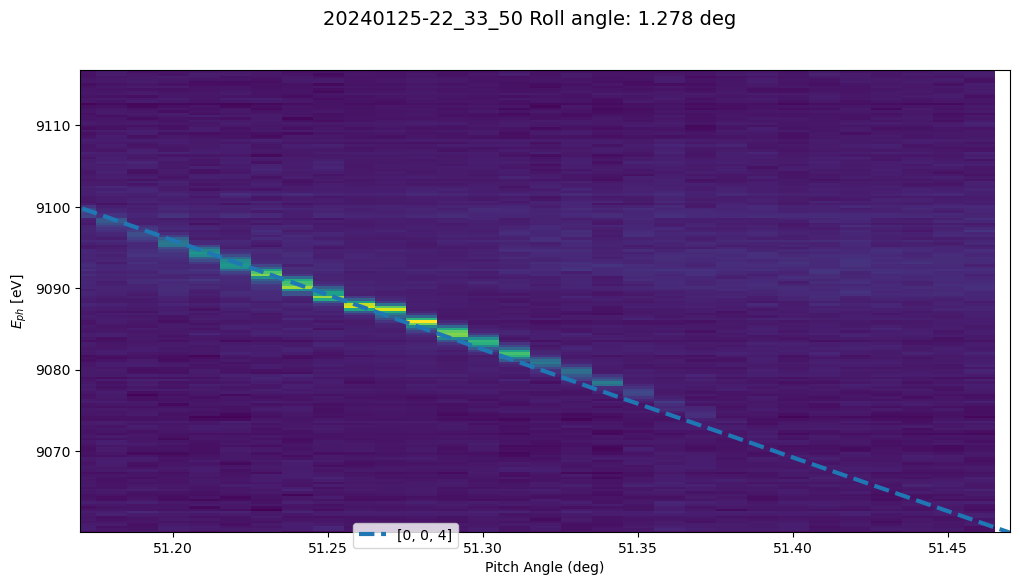

2
Monochromator 2 image found; 
Machine status file found: roll angle=1.2777 deg 



IndexError: index 485 is out of bounds for axis 0 with size 334

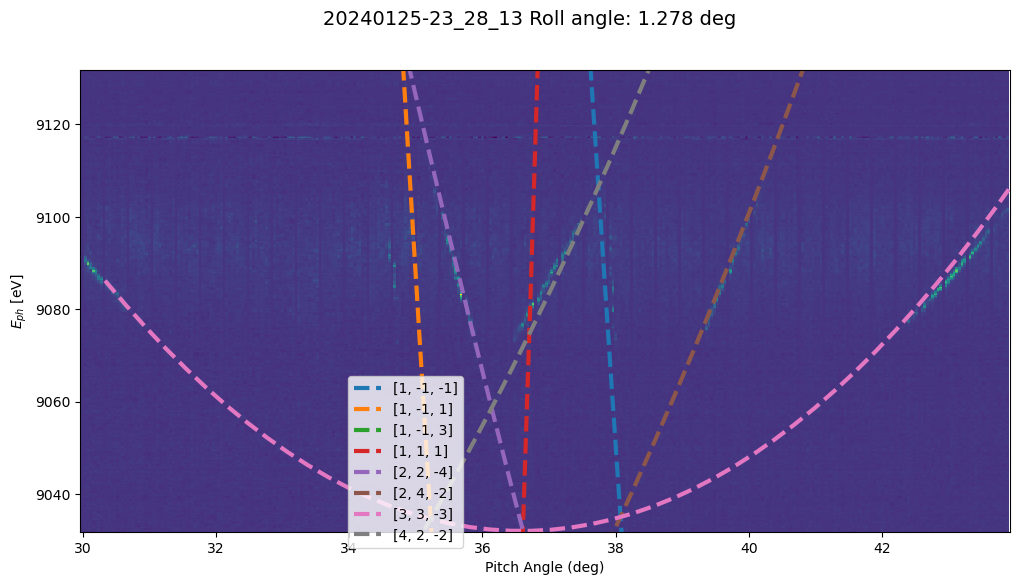

In [178]:
directory = r'Jan2024.nosync/' 
pitch_tot = []
pitch_dict = {}
seeding_energy_tot = []
seeding_energy_dict = {}
roll_tot = []
roll_dict = {}
m=0
datafiles = []
for file in sorted(os.listdir(directory)):  
    filename = os.fsdecode(file)
    if filename.endswith('cor2d.npz'):
        filepath=os.path.join(directory, file)
        datafiles.append(filepath)
        tt = np.load(filepath, allow_pickle=True)
        corr2d = tt['corr2d']
        orig_image = tt['corr2d'].T
        spec_hist = tt['spec_hist']
        doocs_scale = tt['doocs_scale']
        np_phen = tt['phen_scale']+en
        doocs_vals_hist = tt['doocs_vals_hist']
        doocs_label = tt['doocs_channel']
        date_raw=filename[ 0 : 17 ]
        date_time_obj = datetime.strptime(date_raw, '%Y%m%d-%H_%M_%S')
        # check if the image corresponds to a crystal pitch angle scan. MONOPA 
        if "XFEL.FEL/UNDULATOR.SASE2/MONOPA.2252.SA2/ANGLE" in doocs_label or "XFEL.FEL/UNDULATOR.SASE2/MONOPA.2307.SA2/ANGLE" in doocs_label:
            date_raw=filename[ 0 : 17 ]
            date_time_obj = datetime.strptime(date_raw, '%Y%m%d-%H_%M_%S') #strip date from image filename
            m=m+1
            print(m)
            # Search for corresponding roll angle from the status file or the database pickle file.
            if "XFEL.FEL/UNDULATOR.SASE2/MONOPA.2252.SA2/ANGLE" in doocs_label: 
                mono_no_pitch = 1
                try:
                    filedata = np.loadtxt(
                        filepath+'_status.txt', dtype='str', delimiter=',', skiprows=1)
                    ra_pos = np.where(
                        filedata == 'XFEL.FEL/UNDULATOR.SASE2/MONORA.2252.SA2/ANGLE')
                    ra_row = ra_pos[0][0]
                    roll_angle = float(filedata[ra_row][1])
                    print('Monochromator 1 image found; \nMachine status file found: roll angle=' + str(np.round(roll_angle, 4)) + ' deg \n')
                except:
                    try:
                        berlin = pytz.timezone('Europe/Berlin')
                        df_db['date_full'] = pd.to_datetime(df_db['date_full'], utc=True)
                        df_db['date_full'] = df_db['date_full'].dt.tz_convert("Europe/Paris")
                        dt = date_time_obj
                        dt = dt.replace(tzinfo=berlin)
                        roll = df_db['roll_angle'].loc[(df_db['date_full'] == nearest(df_db['date_full'], dt)) ]
                        roll_angle = float(roll.iloc[0])
                        print('Monochromator 1 image found; from database: roll angle=' + str(np.round(roll_angle, 4)) + ' deg \n')
                    except:
                        roll_angle = 1
                        print('Monochromator 1 image found; Default roll angle set (1 deg).')
            elif "XFEL.FEL/UNDULATOR.SASE2/MONOPA.2307.SA2/ANGLE" in doocs_label:
                mono_no_pitch = 2
                try:
                    filedata = np.loadtxt(
                        filepath+'_status.txt', dtype='str', delimiter=',', skiprows=1)
                    ra_pos = np.where(
                        filedata == 'XFEL.FEL/UNDULATOR.SASE2/MONORA.2307.SA2/ANGLE')
                    ra_row = ra_pos[0][0]
                    roll_angle = float(filedata[ra_row][1])
                    print('Monochromator 2 image found; \nMachine status file found: roll angle=' + str(np.round(roll_angle, 4)) + ' deg \n')
                except:
                    try:
                        berlin = pytz.timezone('Europe/Berlin')
                        df_db['date_full'] = pd.to_datetime(df_db['date_full'], utc=True)
                        df_db['date_full'] = df_db['date_full'].dt.tz_convert("Europe/Paris")
                        dt = date_time_obj
                        dt = dt.replace(tzinfo=berlin)
                        roll = df_db['roll_angle'].loc[(df_db['date_full'] == nearest(df_db['date_full'], dt)) ]
                        roll_angle = float(roll.iloc[0])
                        print('Monochromator 2 image found; from database: roll angle=' + str(np.round(roll_angle, 4)) + ' deg \n')
                    except:
                        roll_angle = 1
                        print('Monochromator 2 image found; Default roll angle set (1 deg).')
            else: 
                mono_no_pitch = 0
                print('No roll angle')
                

        if len(doocs_scale) != len(orig_image):
            np_doocs=doocs_scale[:-1]
        else:
            np_doocs=doocs_scale
            
         # Original image plot
        fig, ax = plt.subplots(1, 1, figsize=(12, 6))
        fig.suptitle(date_raw+' Roll angle: '+str(np.round(roll_angle,3))+' deg', fontsize=14)
        
        plot = ax.pcolormesh(np_doocs, np_phen, orig_image, cmap='viridis', shading='auto')
        phen_list, p_angle_list, gid_list, linestyle_list, color_list = Bragg_plotter(hmax, kmax, lmax, dthp, dthy, dthr, alpha, roll_angle)
        
        for phen, pangle, gid in zip(phen_list, p_angle_list, gid_list):
            ph_axis, pa_axis = [], []
            for ph_value, pa_value in zip(phen, pangle):
                # Only keep photon energies within a close range of the spectrometer image range
                if ph_value > np_phen[0]-170 and ph_value < np_phen[-1]+170 and pa_value >= min(doocs_scale)-1.2 and pa_value <= max(doocs_scale)+1.2:
                    ph_axis.append(ph_value)
                    pa_axis.append(pa_value)
            if ph_axis == []:
                pass
            else:
                plt.plot(pa_axis, ph_axis, '--', label=gid, linewidth=3)
                pass
                #ax[1].plot(pa_axis, ph_axis, '-.', label=gid)
        ax.set_xlabel('Pitch Angle (deg)')
        ax.set_ylabel(r'$E_{ph}$ [eV]')
        ax.set_ylim(np_phen[0], np_phen[-1])
        ax.set_xlim(doocs_scale[0], doocs_scale[-1])
        ax.legend(loc=8, bbox_to_anchor=(0.35,-0.05))


        #extract pitch, roll and energy
        


        filter_arr = []
        seeding_energy = []
        thres = 150#orig_image.max()/8


        # en = 72
        #x = np_phen
        for spectrum in spec_hist:
            E0=9000
            px1=420
            ev_px = 0.3
            
            start = E0 - px1*ev_px
            stop = E0 + (1280 - px1) * ev_px
            x = np.linspace(start, stop, num=1280)
            

            if np.max(spectrum) > thres: ## Adjust this number to adjust threshold 
                filter_arr.append(True)
                seeding_energy.append(x[np.argmax(spectrum)]+en)
            else:
                filter_arr.append(False)
        
        #seems to be somewhat incorrect --> use different
        # for idx,spectrum in enumerate(corr2d):
        #     x = np_phen
        #     if np.max(spectrum) > thres: ## Adjust this number to adjust threshold 
        #         filter_arr.append(True)
        #         seeding_energy.append(x[np.argmax(spectrum)])
        #     else:
        #         filter_arr.append(False)

        pitch = tt['doocs_vals_hist'][filter_arr]
       # pitch = np_doocs[filter_arr]
        roll = np.ones(pitch.size)*roll_angle
        pitch_tot += pitch.tolist()
        roll_tot += roll.tolist()
        seeding_energy_tot += seeding_energy
        pitch_dict[str(m)] = pitch
        roll_dict[str(m)] = roll_angle
        seeding_energy_dict[str(m)] = seeding_energy
        
        ax.scatter(pitch,seeding_energy,color='r',marker='x')

        plt.show()

        
        #if m ==13:
        #    break
        



In [181]:
test = np.load(datafiles[0],allow_pickle=True)

In [188]:
m=0
for file in sorted(os.listdir(directory)):  
    filename = os.fsdecode(file)
    if filename.endswith('cor2d.npz'):
        filepath=os.path.join(directory, file)
        datafiles.append(filepath)
        tt = np.load(filepath, allow_pickle=True)
        corr2d = tt['corr2d']
        orig_image = tt['corr2d'].T
        spec_hist = tt['spec_hist']
        doocs_scale = tt['doocs_scale']
        np_phen = tt['phen_scale']+en
        doocs_vals_hist = tt['doocs_vals_hist']
        doocs_label = tt['doocs_channel']
        m+=1
        print(m)
        print(spec_hist.shape)
        print(doocs_scale.shape)
        print(doocs_vals_hist.shape)
        print("\n")
        # if m>5:
        #     break


1
(2393, 190)
(31,)
(2393,)


2
(2235, 1280)
(350,)
(2235,)


3
(3037, 1280)
(426,)
(3037,)




4
(3723, 1280)
(546,)
(3723,)


5
(808, 1280)
(69,)
(808,)


6
(1463, 1280)
(130,)
(1463,)


7
(2598, 1280)
(222,)
(2598,)


8
(1702, 1280)
(191,)
(1702,)


9
(4005, 1280)
(239,)
(4005,)


10
(936, 1280)
(153,)
(936,)


11
(1312, 1280)
(202,)
(1312,)


12
(1921, 1280)
(262,)
(1921,)


13
(798, 1280)
(132,)
(798,)


14
(986, 1280)
(167,)
(986,)


15
(475, 1280)
(85,)
(475,)


16
(643, 1280)
(102,)
(643,)


17
(1210, 1280)
(103,)
(1210,)


18
(787, 1280)
(103,)
(787,)


19
(953, 1280)
(103,)
(953,)


20
(1091, 1280)
(81,)
(1091,)


21
(274, 1280)
(48,)
(274,)


22
(1098, 1280)
(105,)
(1098,)


23
(1505, 1280)
(127,)
(1505,)


24
(866, 1280)
(103,)
(866,)


25
(2224, 1280)
(157,)
(2224,)


26
(1027, 1280)
(127,)
(1027,)


27
(1277, 1280)
(153,)
(1277,)


28
(1261, 1280)
(153,)
(1261,)


29
(1319, 1280)
(145,)
(1319,)


30
(1012, 1280)
(145,)
(1012,)


31
(1028, 1280)
(136,)
(1028,)


32
(878, 1280)
(102,)
(878,)


33
(1567, 1280)
(42,)
(1567,)


34
(2505, 1280)
(63,)
(2505,)


35
(1266, 1

In [135]:
orig_image.shape

(266, 62)

In [ ]:
(orig_image.shape,np_doocs.shape,np_phen.shape)

((266, 62), (62,), (266,))

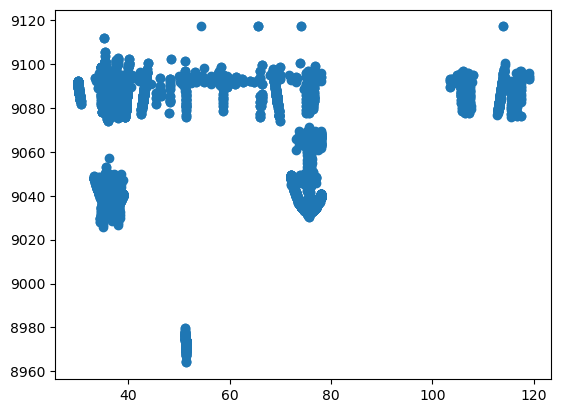

In [ ]:
roll_set = roll_tot[0]
roll_bool = np.array(roll_tot)==roll_set
plt.scatter(np.array(pitch_tot)[roll_bool],np.array(seeding_energy_tot)[roll_bool])

array([ True,  True,  True, ...,  True,  True,  True])

In [ ]:
## 

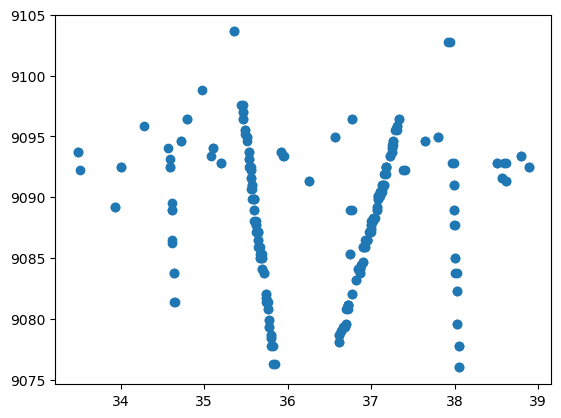

In [ ]:
plt.scatter(pitch_dict["29"],seeding_energy_dict["29"])

### Extract lines from spectral data for specific set

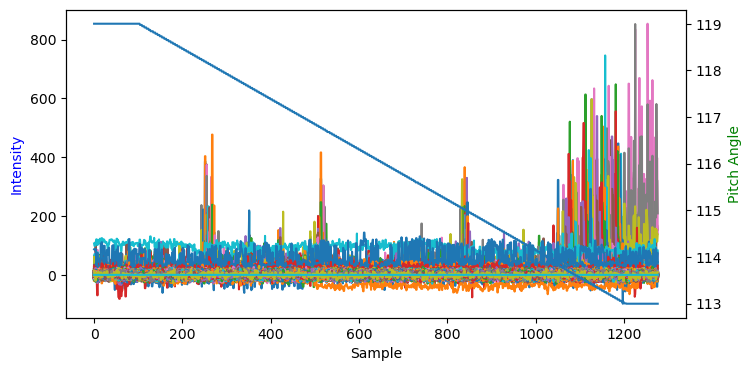

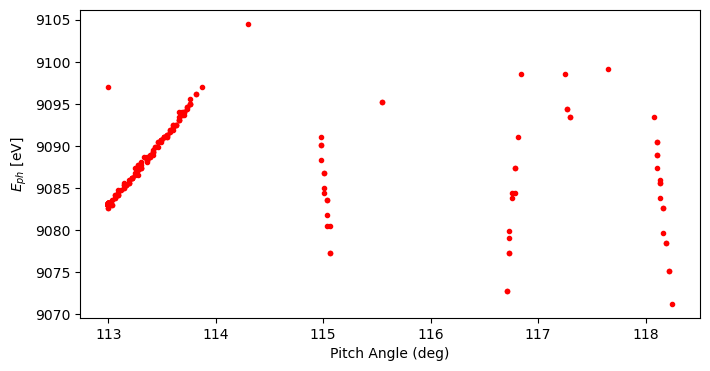

In [ ]:
fidx = 27
tt = np.load(datafiles[fidx-1], allow_pickle=True)
fig, ax1 = plt.subplots(figsize=(8,4))
ax2 = ax1.twinx()

ax1.plot(tt['spec_hist'])
ax2.plot(tt['doocs_vals_hist'])

ax1.set_xlabel('Sample')
ax2.set_ylabel('Pitch Angle', color='g')
ax1.set_ylabel('Intensity', color='b')
#plt.xlim(16300, 16700)
plt.show()

filter_arr = []
seeding_energy = []
en = 72
for spectrum in tt['spec_hist']:
    E0=9000
    px1=420
    ev_px = 0.3
    
    start = E0 - px1*ev_px
    stop = E0 + (1280 - px1) * ev_px
    x = np.linspace(start, stop, num=1280)

    if np.max(spectrum) > 150: ## Adjust this number to adjust threshold 
        filter_arr.append(True)
        seeding_energy.append(x[np.argmax(spectrum)]+en)
    else:
        filter_arr.append(False)
pitch = tt['doocs_vals_hist'][filter_arr]
# Plot extracted lines
fig, ax = plt.subplots(figsize=(8,4))
plt.plot(pitch, seeding_energy, 'r.')
ax.set_xlabel('Pitch Angle (deg)')
ax.set_ylabel(r'$E_{ph}$ [eV]')
plt.show()

## use dynamic diffraction module

In [ ]:
from dynamic_diffraction_module import *

bm = bmirror
from dynamic_diffraction_module import material_data as md
from dynamic_diffraction_module.utils import *

Importing bmirror class, crystal class and Constants from dynamic-diffraction-module.


In [ ]:
cr = crystal()
#cr.set_crystal_planes("111")
cr.set_crystal_planes("100")
cr.Tbase = 293#300
cr.thickness = 100E-6

cr.pitch = np.deg2rad(90)#np.pi/2
cr.roll = 0
#setting the Bragg angle to a specific degree
#Theta_B = deg2rad(45.)
#cr.roll = np.arccos(np.sin(Theta_B)/#np.sin(cr.pitch))
cr.calc_RLab2Cryst()
#H0 = np.array([3, 3, 3])
H0 = np.array([4, 0, 0])
bmir = bm(H0, cryst=cr)

initializing Bragg mirror from predefined crystal


### try fitting using dyn_diff_mod

In [ ]:
fidx = 27
pitches = pitch_dict[str(fidx)]
Eoffset_pre = 0#20
Eph_seed = np.array(seeding_energy_dict[str(fidx)])+Eoffset_pre
roll = roll_dict[str(fidx)]

In [ ]:
#bmir.cryst.yaw = np.deg2rad(dY)
Pitch = np.deg2rad(pitches)
PreSampling = bmir.BraggCurvesEvsAngles_inRange((Eph_seed.min()-20,Eph_seed.max()+20),PitchRange=[Pitch.min(),Pitch.max()],RollRange=np.deg2rad(roll),numPreSampling=1000)
Hquery = PreSampling[1]

In [ ]:
Hquery

array([array([-1, -3,  1]), array([-3,  1, -1]), array([-1, -1,  3]),
       array([-5, -1,  1])], dtype=object)

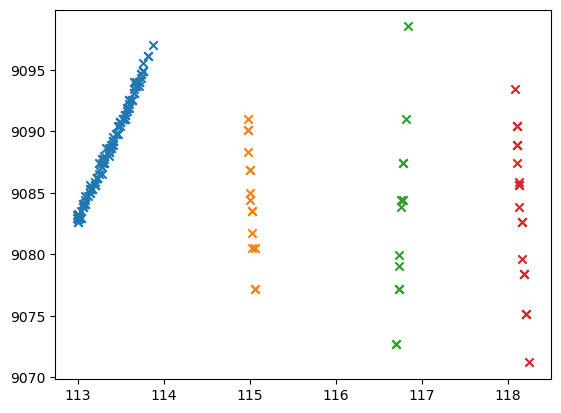

In [ ]:
dP_split = 0.4
dE_del = 10
sort = np.argsort(pitches)
pitch_sort = pitches[sort]
Eph_sort = Eph_seed[sort]

splitIdx = np.append(np.append([0],np.arange(1,pitch_sort.size)[np.diff(pitch_sort)>dP_split]),[pitch_sort.size])
pitches_H = [pitch_sort[splitIdx[idx]:splitIdx[idx+1]] for idx in range(splitIdx.size-1)]
E_H = [Eph_sort[splitIdx[idx]:splitIdx[idx+1]] for idx in range(splitIdx.size-1)]


del_bool_l = np.array([pline.size<8 for pline in pitches_H])
for lidx in range(del_bool_l.size-1,0-1,-1):
    if del_bool_l[lidx]:
        del (pitches_H[lidx])
        del (E_H[lidx])

# pitches_H[0]=np.delete(pitches_H[0],0)
# E_H[0]=np.delete(E_H[0],0)
for lidx in range(len(pitches_H)):
    dEH = np.diff(E_H[lidx])
    idx = np.hstack((True,dEH < dE_del))
    E_dummy = E_H[lidx][idx]
    pitches_dummy = pitches_H[lidx][idx]
    E_H[lidx] = E_dummy
    pitches_H[lidx] = pitches_dummy

    plt.scatter(pitches_dummy,E_dummy,marker='x')

### get an idea about the actual angles

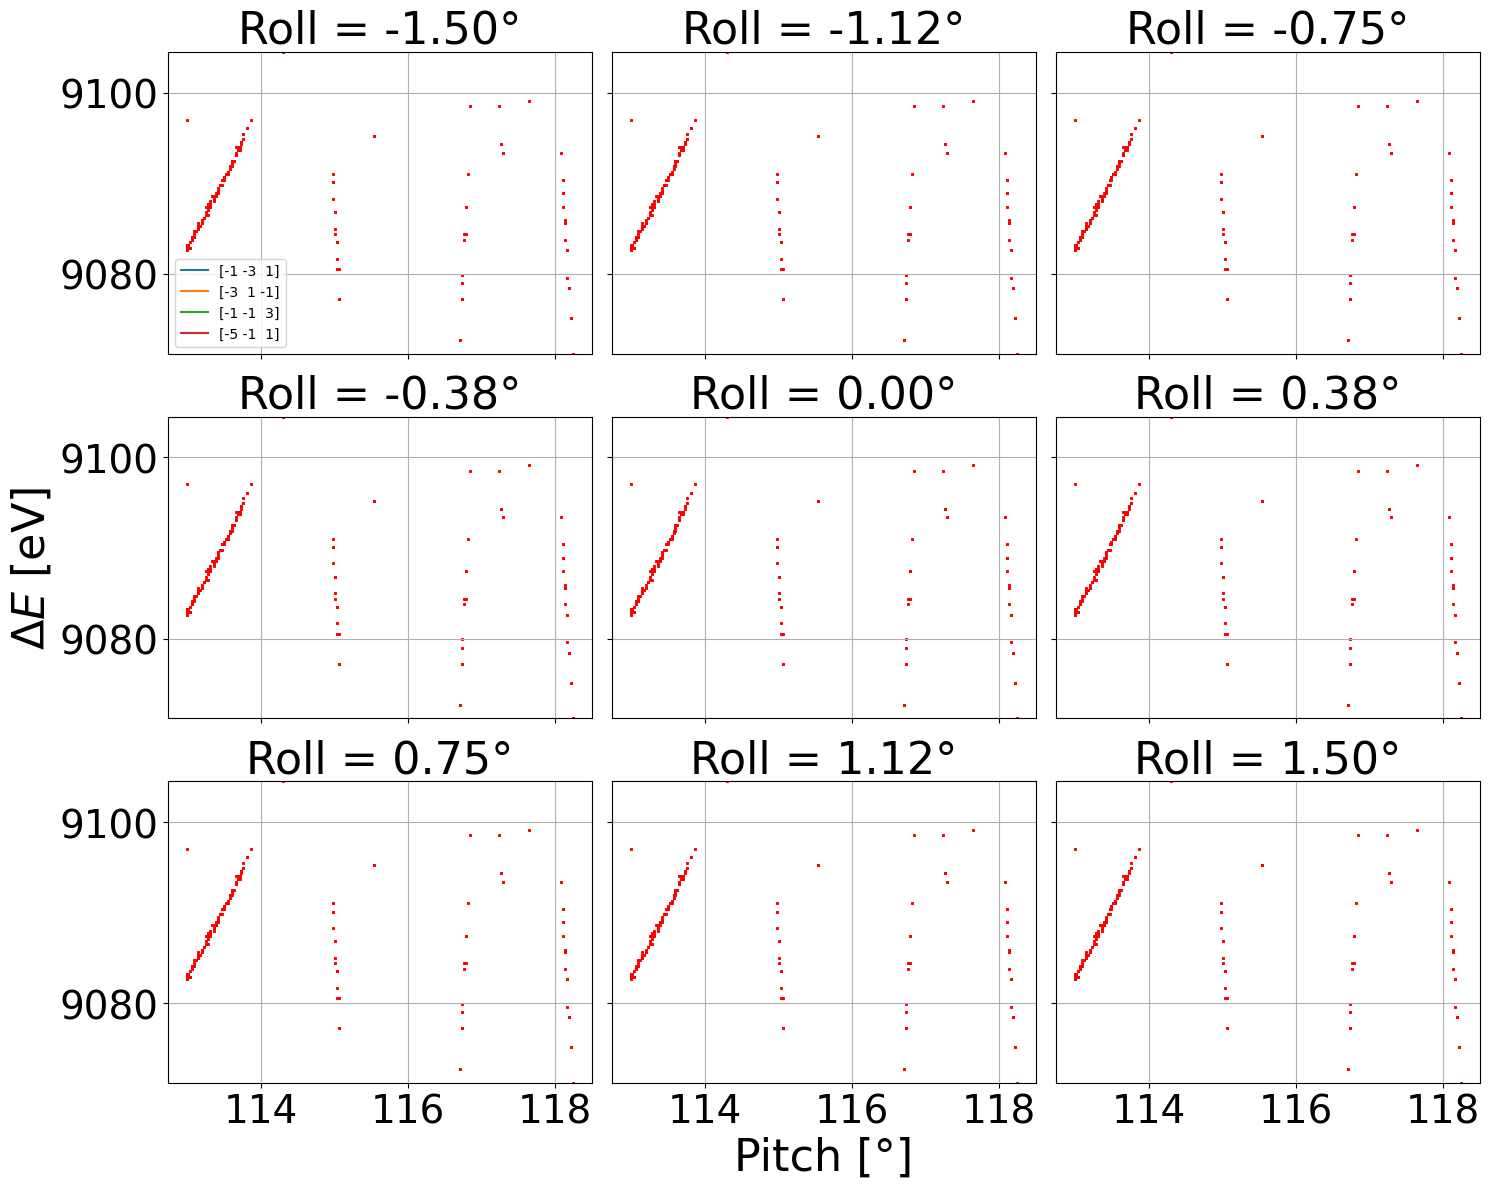

In [ ]:
RollQuery = np.deg2rad(np.linspace(-1.5,1.5,9))
Yaw = -dY#np.deg2rad()
bmir.cryst.yaw = Yaw
dP = -dP
Eoffset = -Ecorr
EBragg = np.zeros((RollQuery.size,Pitch.size,Hquery.size))
for Ridx, Roll in enumerate(RollQuery):
    bmir.cryst.roll = Roll+np.deg2rad(roll)
    for Pidx,P in enumerate(Pitch):
        bmir.cryst.pitch = P+np.deg2rad(dP)
        for Hidx,H in enumerate(Hquery):
            bmir.initialize()
            EBragg[Ridx,Pidx,Hidx] = bmir.bragg_wavelength(H=H)[1]-Eoffset

# now parse 
fig_parse, axs = plt.subplots(nrows=3,ncols=3,tight_layout=True,figsize=(15,12))
ylims = np.array([Eph_seed.min(),Eph_seed.max()])
#ylims = [-0.25,0.25]
for idx, ax in enumerate(axs.flatten()):
    #Ridx = idx*int((Roll.size-1)/8)
    ax.tick_params(labelsize=28)
    ax.grid()
    ax.set_title("Roll = {:.2f}°".format(np.rad2deg(RollQuery[idx])),fontsize=32)
    if idx%3>0:
        ax.tick_params(labelleft=False)
    if idx<6:
        ax.tick_params(labelbottom=False)
        #ax.set_xlabel("$\\Delta E$[meV]",fontsize=32)
    for Hidx in range(Hquery.shape[0]):
        ax.scatter(pitches,Eph_seed,color='red',s=1)
        ax.plot(pitches,EBragg[idx,:,Hidx].squeeze(),label=str(Hquery[Hidx]))
        #ax.fill_between((Pitch-np.pi/2)*1E3,(E_Hs[Ridx,:,Hidx]*(1+bw_Hs[Ridx,:,Hidx,0])).squeeze()-bmir.E_c,(E_Hs[Ridx,:,Hidx]*(1+bw_Hs[Ridx,:,Hidx,1])).squeeze()-bmir.E_c)

    ax.set_ylim(ylims)
    #ax.set_xlim((Pitch[0]-np.pi/2)*1E3,(Pitch[-1]-np.pi/2)*1E3)
axs[2,1].set_xlabel("Pitch [°]",fontsize=32)
axs[1,0].set_ylabel("$\\Delta E$ [eV]",fontsize=32)
axs[0,0].legend()

In [ ]:
def HtoMeasf(dP,dR,dY,Ecorr):
    peval = np.linspace(pitches.min(),pitches.max(),num=10001)
    HtoMeas = np.zeros(Hquery.size,dtype=int)
    for Hidx, H  in enumerate(Hquery):
        cost = np.zeros(len(pitches_H))
        for lidx in range(len(pitches_H)):        
            peval = pitches_H[lidx]
            eval = getBragg(np.deg2rad(peval+dP),np.deg2rad(roll+dR),np.deg2rad(dY),H) + Ecorr
            cost[lidx] = np.sum((E_H[lidx]-eval)**2)/peval.size**2
        HtoMeas[Hidx] = cost.argmin()
    return HtoMeas
def getBragg(PQuery,RQuery,YQuery,H):
    bmir.cryst.roll = RQuery 
    bmir.cryst.yaw = YQuery 
    EBraggs = np.zeros(PQuery.size)
    for Pidx,P in enumerate(PQuery):
        bmir.cryst.pitch = P
        bmir.cryst.calc_RLab2Cryst()
        EBraggs[Pidx] = bmir.bragg_wavelength(H=H,exact=False)[1]
    return EBraggs
HtoMeas = [1, 2, 3, 0 ] #HtoMeasf(-1,0.32,4.5,0)
def optFuncp(dP,dR,dY,Ecorr):
    #peval = np.linspace(pitches.min(),pitches.max(),3001)
    cost = 0

    Emid = 0.5*(Eph_seed.min()+Eph_seed.max())
    for Hidx, H in enumerate(Hquery):
        lidx = HtoMeas[Hidx]
        peval = pitches_H[lidx]
        EBraggs = getBragg(np.deg2rad(peval+dP),np.deg2rad(roll+dR),np.deg2rad(dY),H)+Ecorr
        cost += np.sum((EBraggs-E_H[lidx])**2)/peval.size**2

    return 1/cost



[1, 2, 3, 0]


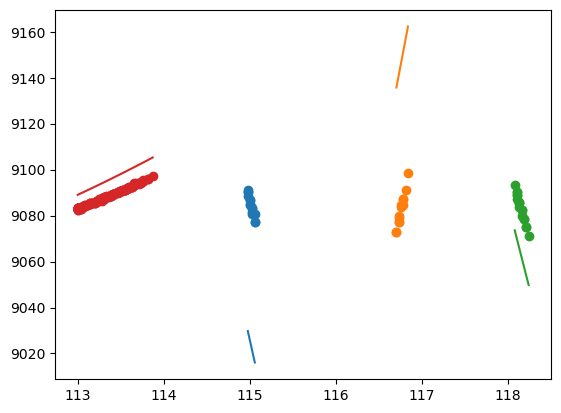

In [ ]:
dP = -1
dR = 0.38
dY = 4.5
HtoMeas = [1, 2, 3, 0 ] #HtoMeasf(-1,0.32,4.5,0)
for Hidx, H in enumerate(Hquery):
    lidx = HtoMeas[Hidx]
    # print(lidx)
    # P0 = P0s[lidx]
    peval = pitches_H[lidx]
    
    #dP, dR, Ecorr = res.x

    EBragg = getBragg(np.deg2rad(peval+dP), np.deg2rad(roll+dR), np.deg2rad(dY), H)
    plt.scatter(pitches_H[lidx],E_H[lidx])
    plt.plot(peval, EBragg)
print(HtoMeas)
#plt.scatter(pitches,Eph_seed,color='red',marker='x')
#plt.ylim(Eph_seed.min(),Eph_seed.max())

### do the actual fit

1
[-1.05  0.4   4.5  10.  ] 444.2650030088619


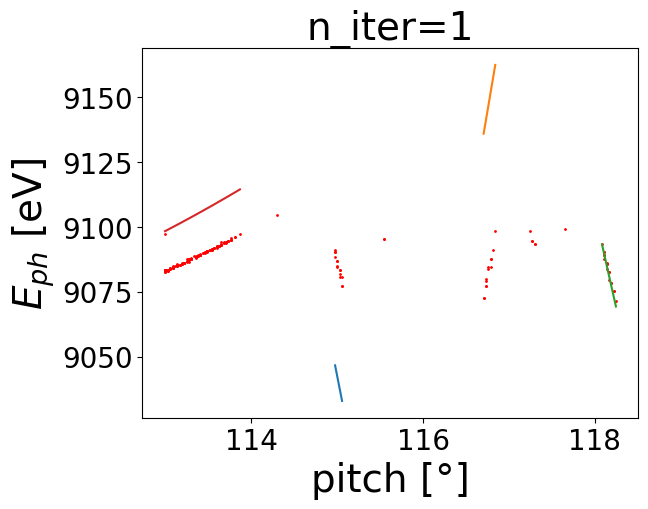

51
[-1.31988078  0.5003579   3.86463393 -3.71345712] 0.5733772049299823


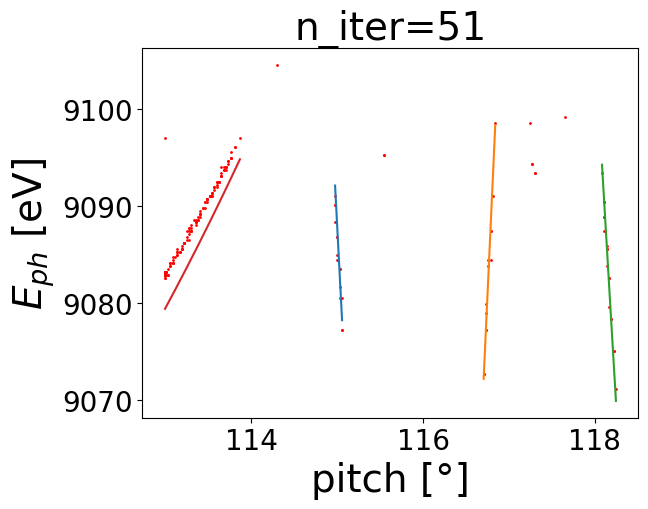

101
[-1.31703597  0.50313368  3.86738149 -4.00136362] 0.4835144017925022


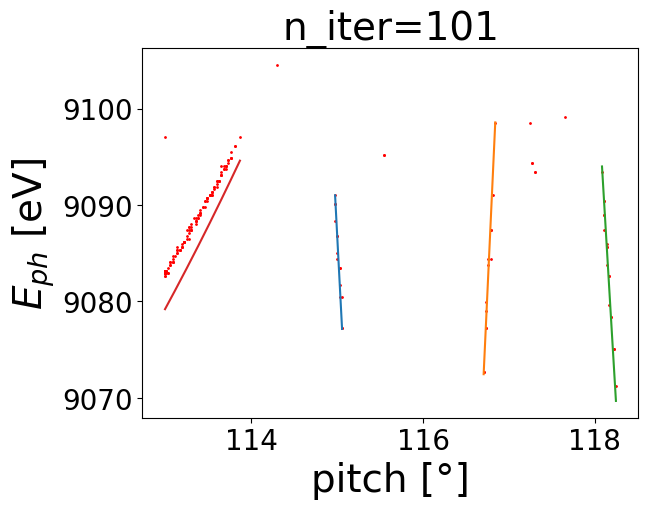

151
[-1.33043501  0.76134892  3.32188117 -3.13041489] 0.45318081495056856


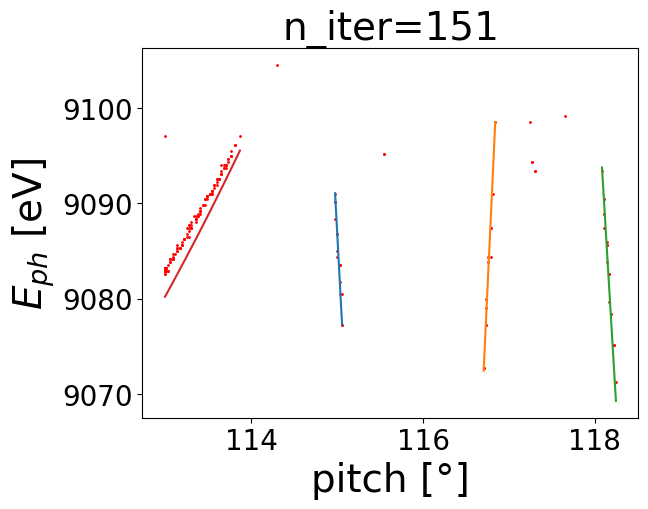

201
[-1.3620808   1.24349476  2.31427468 -1.41828949] 0.4182712702740757


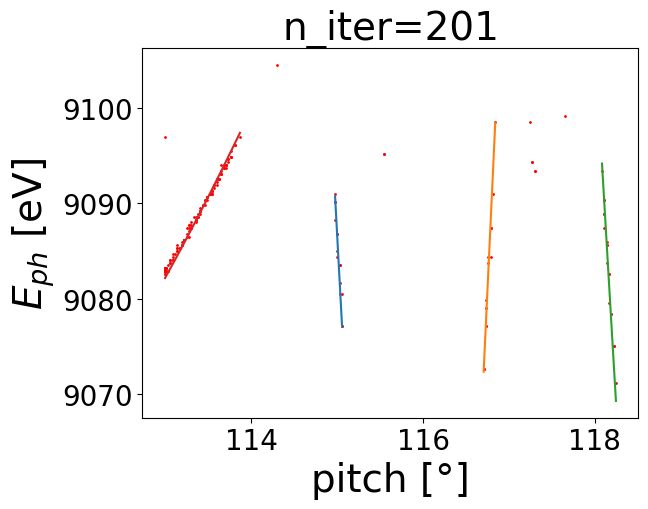

251
[-1.36619242  1.29509198  2.20433319 -1.22463367] 0.41740142357206406


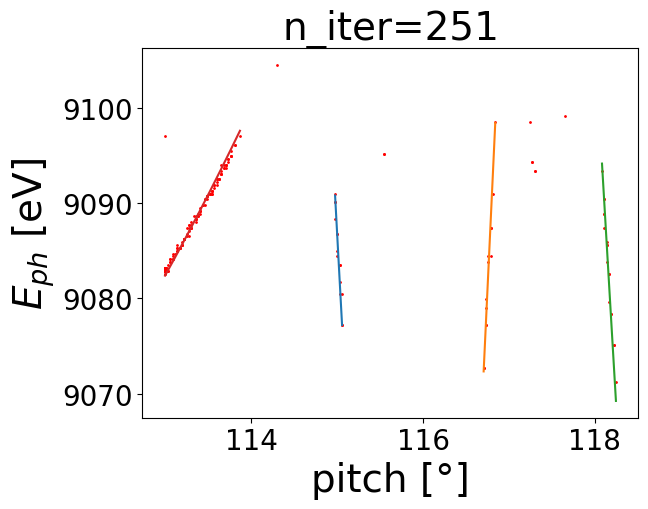

301
[-1.36620953  1.29531582  2.20385814 -1.22391416] 0.41740141336191894


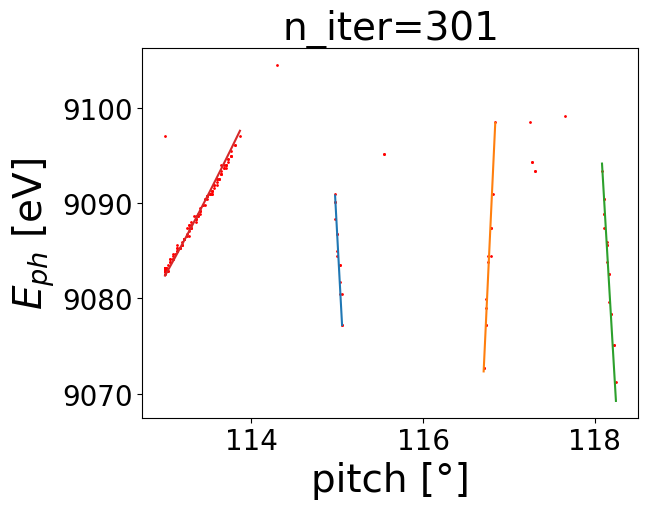

351
[-1.36620953  1.29531582  2.20385814 -1.22391416] 0.41740141336191894


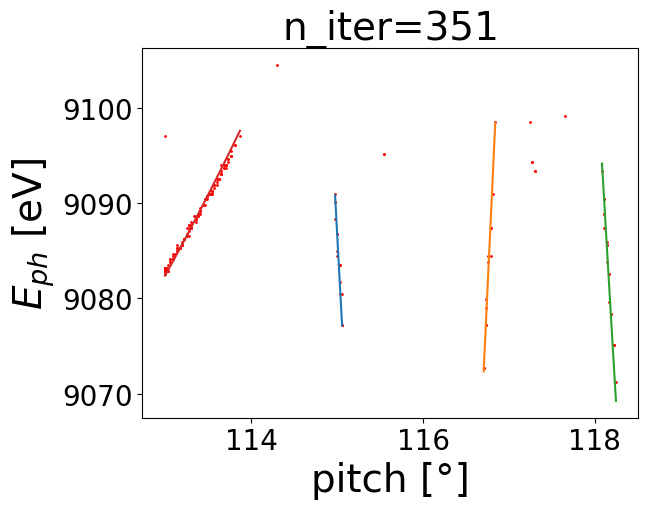

Optimization terminated successfully.
         Current function value: 0.417401
         Iterations: 389
         Function evaluations: 752
390
[-1.36620953  1.29531582  2.20385814 -1.22391416] 0.41740141336176806


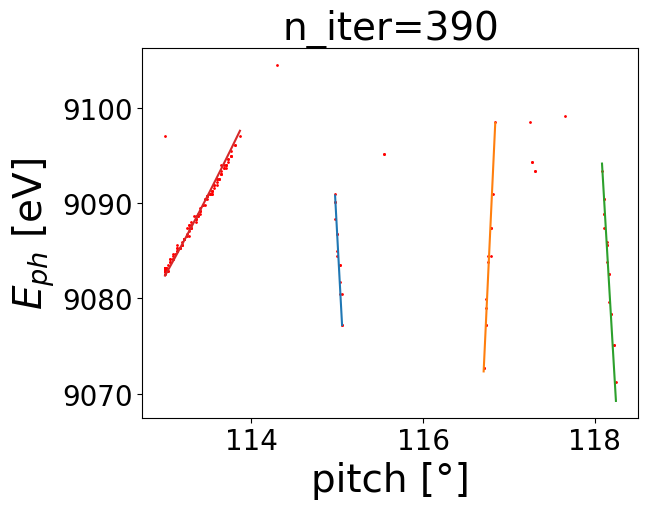

In [ ]:
def optFunc_minimizer(x):
    #return 1/optFuncp(x[0],x[1],x[2],0)
    return 1/optFuncp(x[0],x[1],x[2],x[3])
def display_Func(intermediate_result):
    global forcePlot
    global niter
    niter += 1
    if(niter%50 == 1 or forcePlot):
        print(niter)
        print(intermediate_result.x,intermediate_result.fun)
        plt.title("n_iter="+str(niter),fontsize=28)
        plt.scatter(pitches,Eph_seed,color='red',s=1)
        plt.ylabel("$E_{ph}$ [eV]",fontsize=28)
        plt.xlabel("pitch [°]", fontsize=28)
        plt.tick_params(labelsize=20)
        dP,dR,dY,Ecorr = intermediate_result.x
        #dP,dR,dY = intermediate_result.x
        for Hidx, H in enumerate(Hquery):
            lidx = HtoMeas[Hidx]
            #print(lidx)
            #P0 = P0s[lidx]
            peval = pitches_H[lidx]
            EBragg = getBragg(np.deg2rad(peval+dP),np.deg2rad(roll+dR),np.deg2rad(dY),H)+Ecorr

            #print(peval_sub.min(),peval_sub.max())
            plt.plot(peval,EBragg)
            #plt.ylim(Eph_seed.min(),Eph_seed.max())
        plt.show()

niter = 0
forcePlot = False
x0 = np.array([-1, 0.4, 4.5, 10])
bounds = ([-3,3],[-5,5],[-10,10],[-50,50])
res = opt.minimize(optFunc_minimizer, x0, method='Nelder-Mead',
               options={'xatol': 1e-14,'fatol': 1e-14, 'disp': True,'maxiter':1000},bounds=bounds,callback=display_Func)
forcePlot=True
display_Func(res)

In [ ]:
### plot the individual lines
dP,dR,dY,Ecorr = [-1.36620953,  1.29531582,  2.20385814, -1.22391416-Eoffset_pre]  #res.x
fig, axs = plt.subplots(ncols=3,nrows=np.ceil(Hquery.size/3).astype(int),figsize=(12,12),gridspec_kw={'hspace':0.25})
#dP,dR,dY = intermediate_result.x
for Hidx, H in enumerate(Hquery):
        ax = axs.flatten()[Hidx]
        ax.set_title("H="+str(H),fontsize=24)
        ax.tick_params(labelsize=18)
        lidx = HtoMeas[Hidx]

        #print(lidx)
        #P0 = P0s[lidx]
        peval = pitches_H[lidx]
        EBragg = getBragg(np.deg2rad(peval+dP),np.deg2rad(roll+dR),np.deg2rad(dY),H)+Ecorr
        #print(peval_sub.min(),peval_sub.max())
        ax.plot(peval,EBragg)
        ax.scatter(pitches_H[lidx],E_H[lidx],marker='x',color='red')

### use the fit parameters for the other measurements --> not really good

0


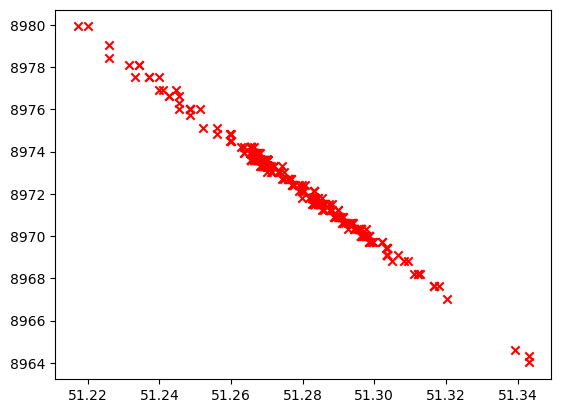

1


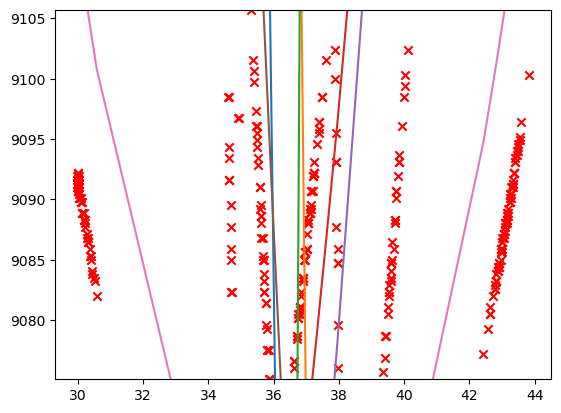

2


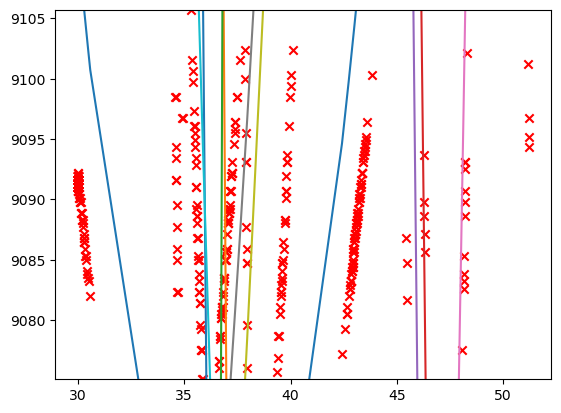

3


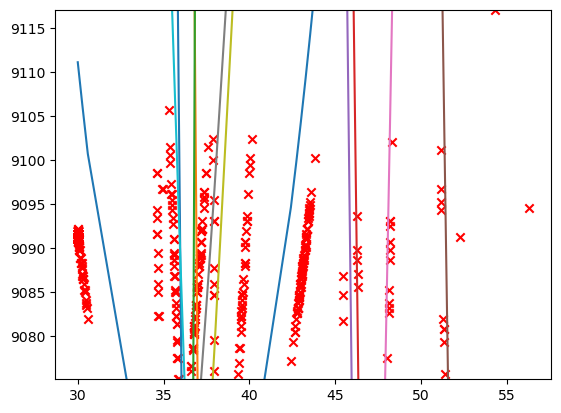

4


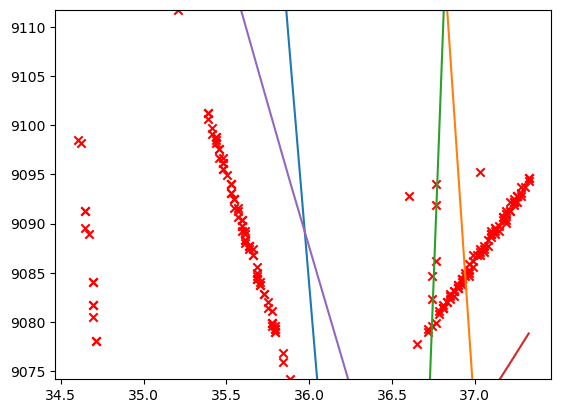

5


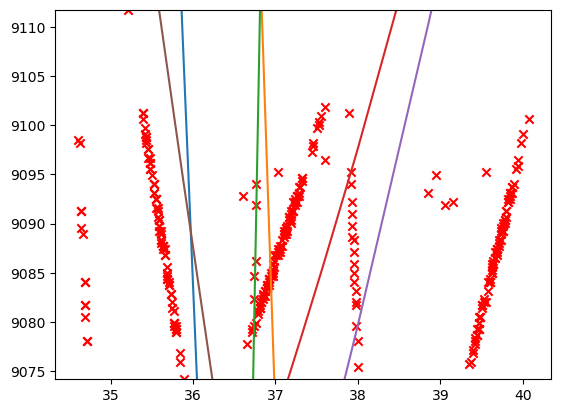

6


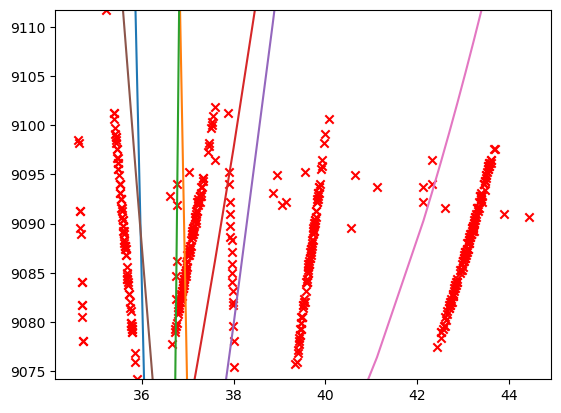

7


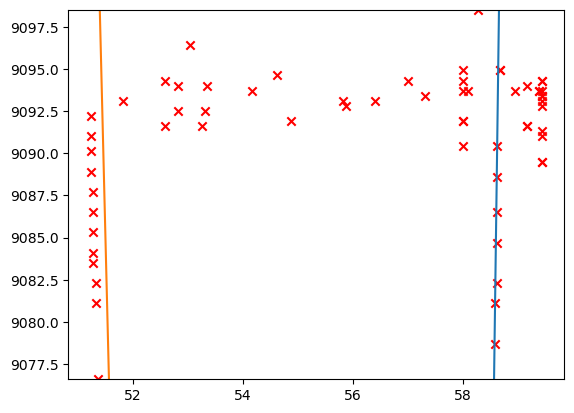

8


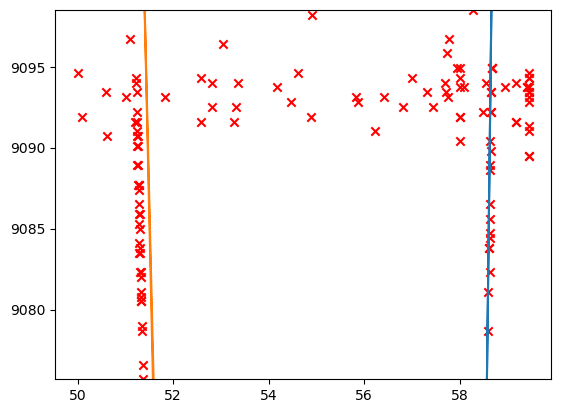

9


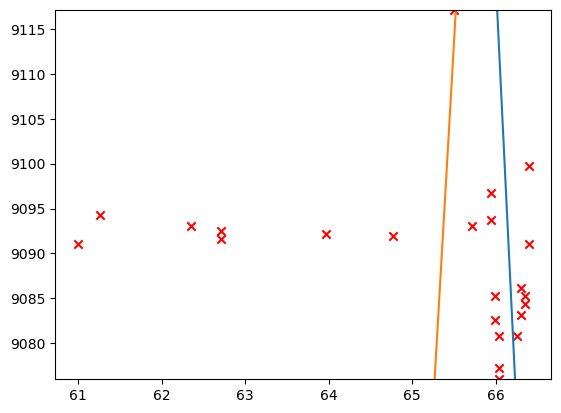

10


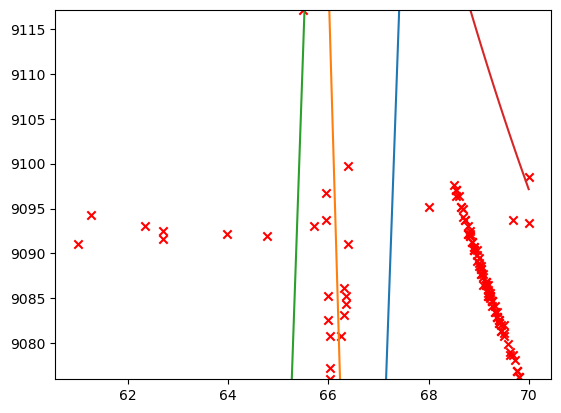

11


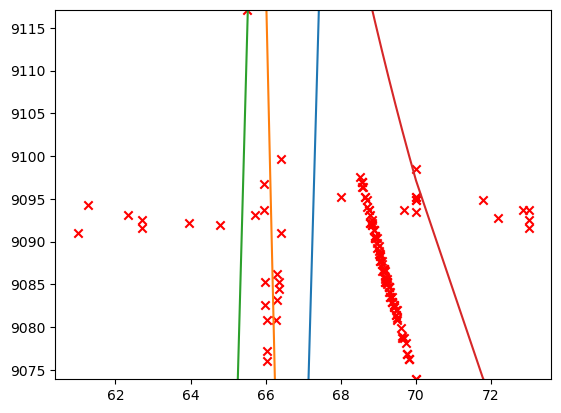

12


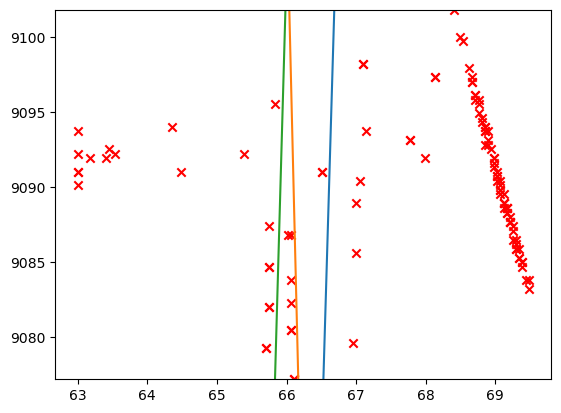

13


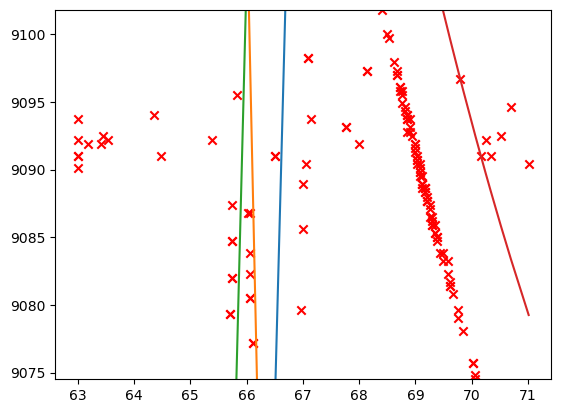

14


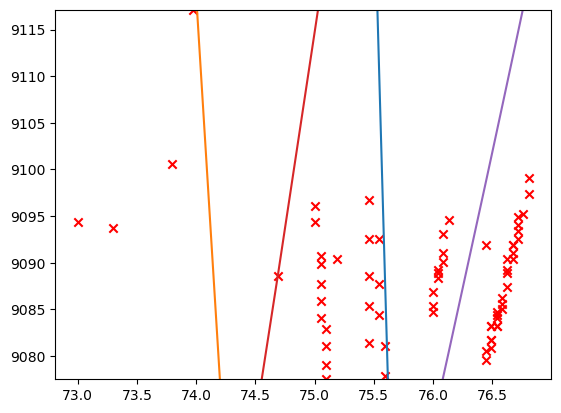

15


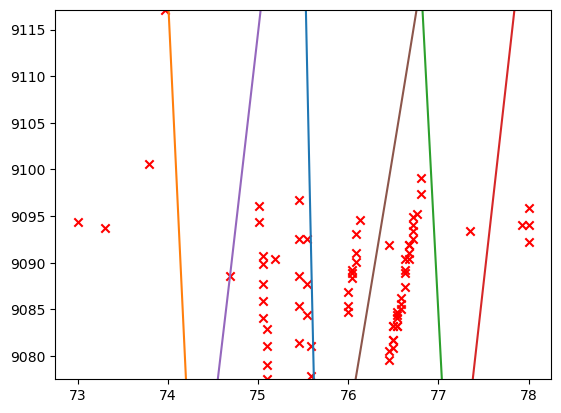

16


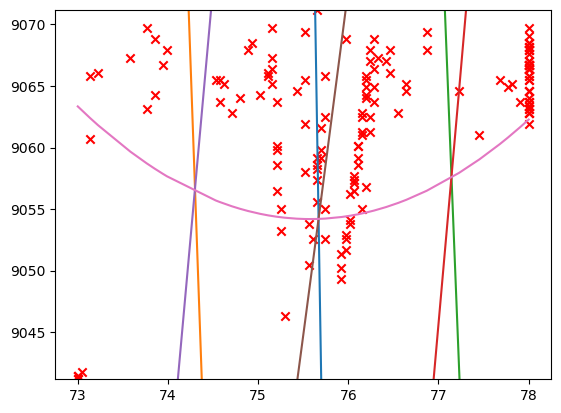

17


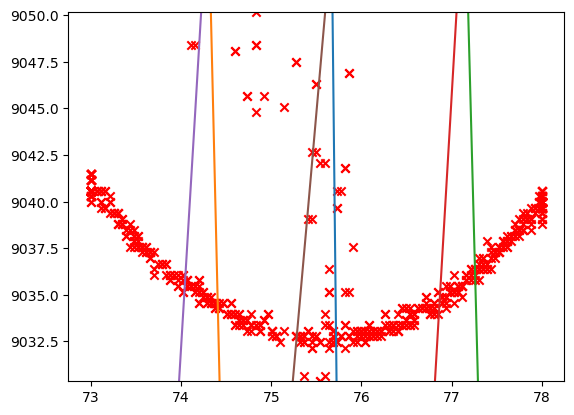

18


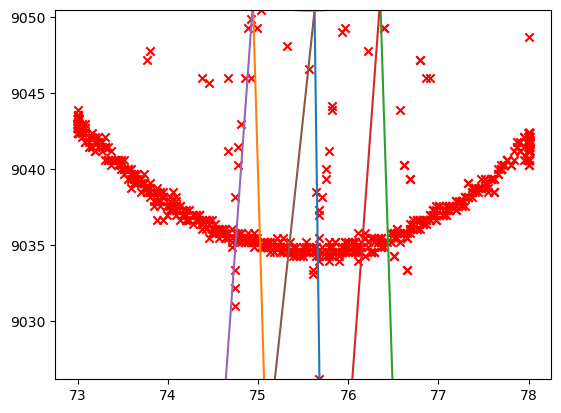

19


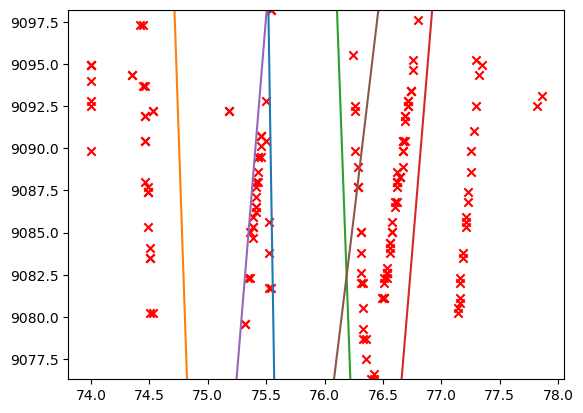

20


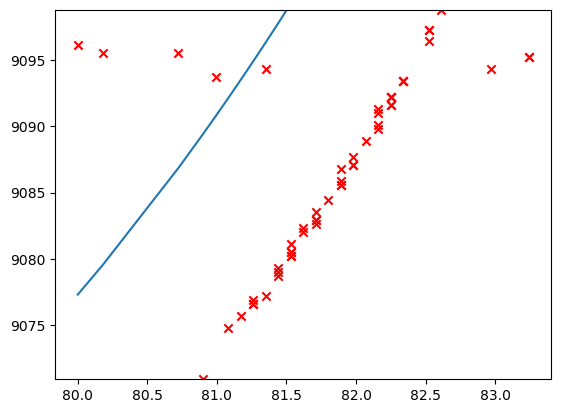

21


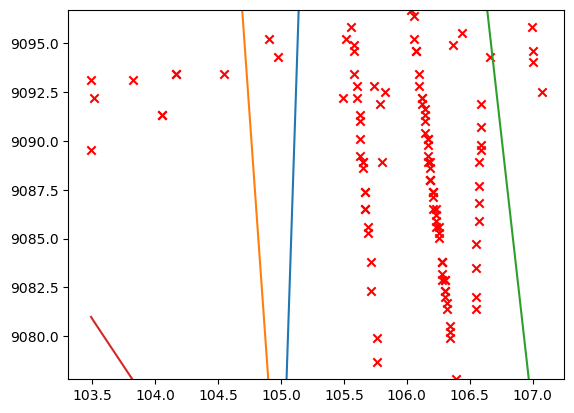

22


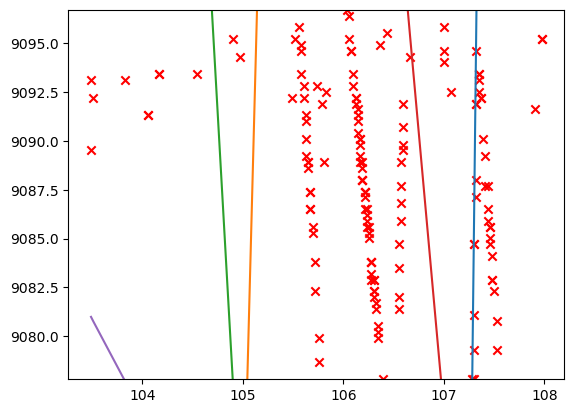

23


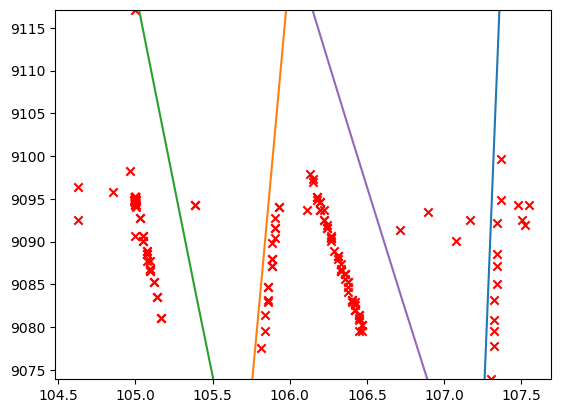

24


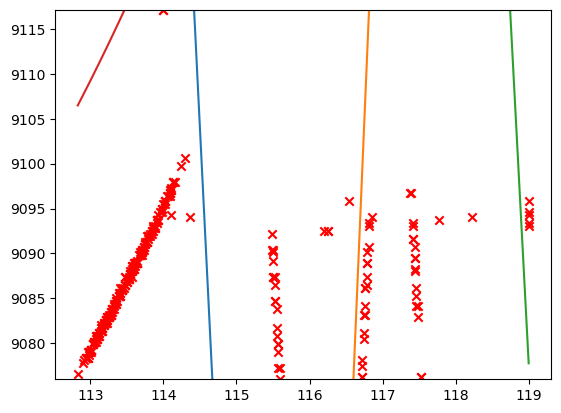

25


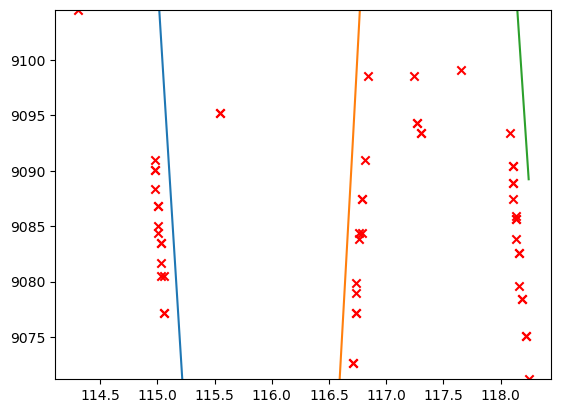

26


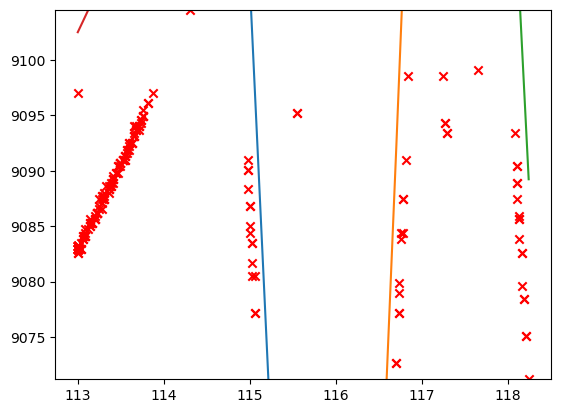

27


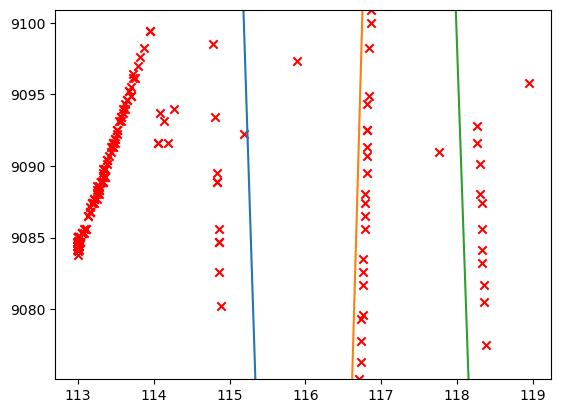

28


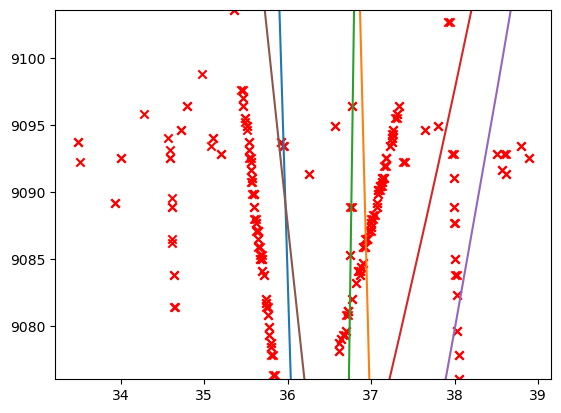

29


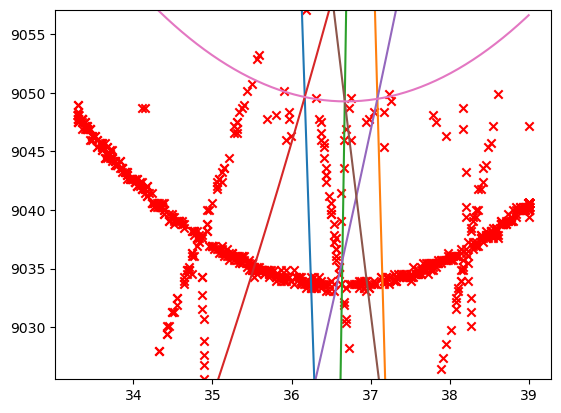

30


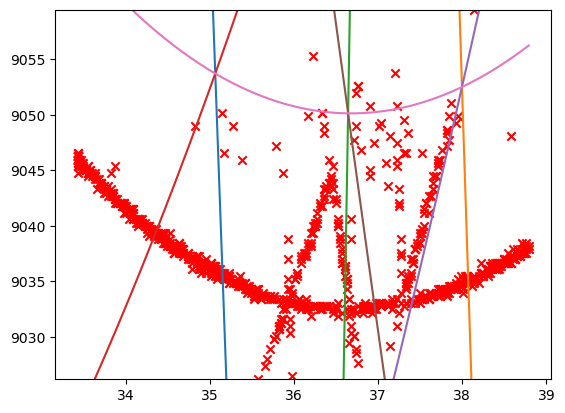

31


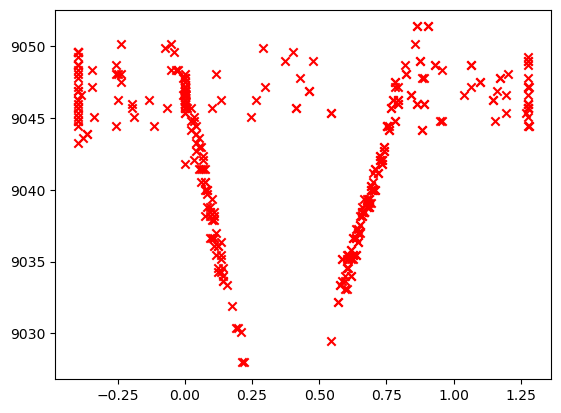

32


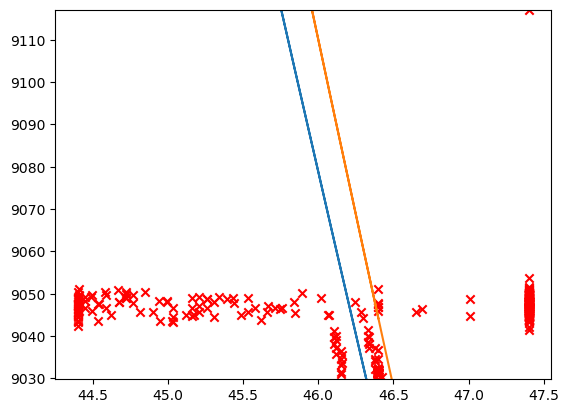

33


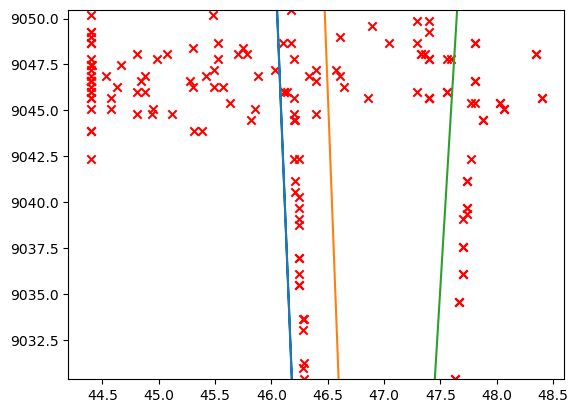

34


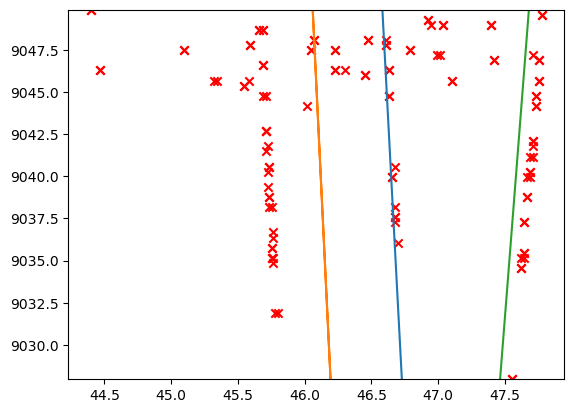

35


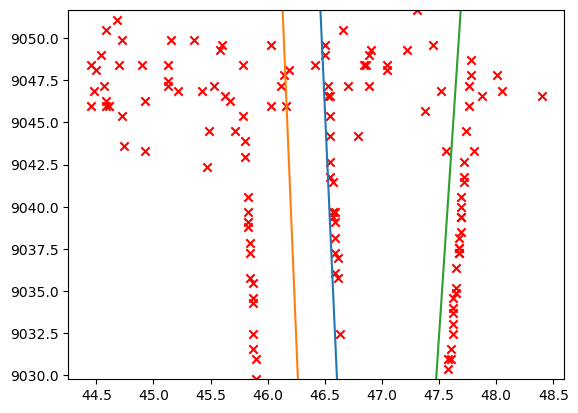

36


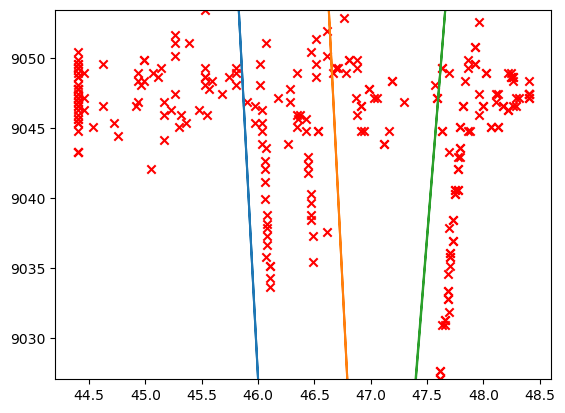

37


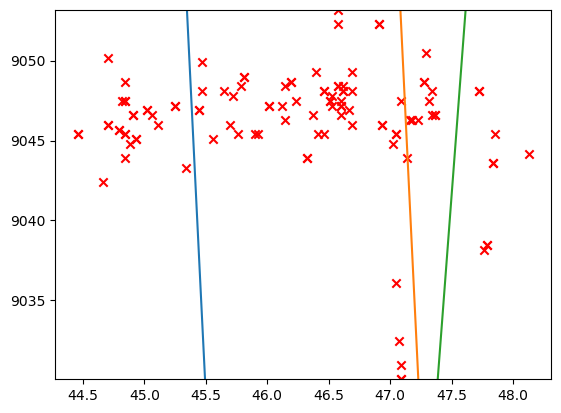

38


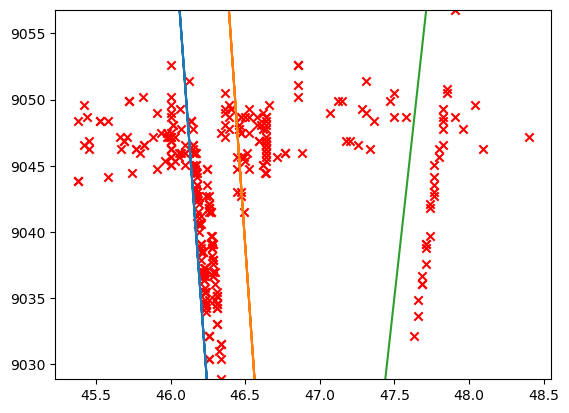

39


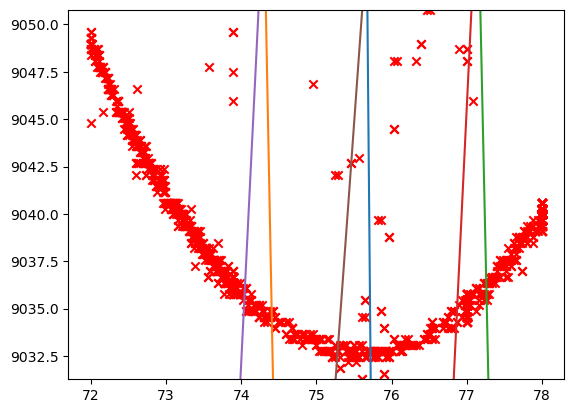

In [ ]:
for m in range(len(pitch_dict)):#1):#
    print(m)
    plt.figure()
    pitches = pitch_dict[str(m+1)]
    roll = roll_dict[str(m+1)]
    Eph_seed = np.array(seeding_energy_dict[str(m+1)])
    Pitch = np.deg2rad(pitches+dP)
    bmir.cryst.yaw = np.deg2rad(dY)
    PreSampling = bmir.BraggCurvesEvsAngles_inRange((Eph_seed.min()-30,Eph_seed.max()+30),PitchRange=[Pitch.min(),Pitch.max()],RollRange=np.deg2rad(roll+dR),numPreSampling=1000)
    Hquery_i = PreSampling[1]
    plt.scatter(pitches,Eph_seed,marker='x',color='red')
    for Hidx, H in enumerate(Hquery_i):
        #print(lidx)
        #P0 = P0s[lidx]
        
        EBragg = getBragg(Pitch,np.deg2rad(roll+dR),np.deg2rad(dY),H)+Ecorr

        #print(peval_sub.min(),peval_sub.max())
        plt.plot(pitches,EBragg)
        
        plt.ylim(Eph_seed.min(),Eph_seed.max())
    plt.show()

    

## try different model with pitch dependent roll offset

In [137]:
def getBragg_wPRcorr(PQuery,RQuery,YQuery,dPR,H):
    bmir.cryst.yaw = YQuery 
    EBraggs = np.zeros(PQuery.size)
    for Pidx,P in enumerate(PQuery):
        bmir.cryst.roll = RQuery + dPR*np.abs(P-np.pi/2)
        bmir.cryst.pitch = P
        bmir.cryst.calc_RLab2Cryst()
        EBraggs[Pidx] = bmir.bragg_wavelength(H=H,exact=False)[1]
    return EBraggs
def HtoMeasf_acc(pitches,rolls,E_H,Hquery,dP,dR,dPR,dY,Ecorr):
    HtoMeas = np.zeros(Hquery.size,dtype=int)
    for Hidx, H  in enumerate(Hquery):
        cost = np.zeros(len(pitches))
        for lidx in range(len(pitches)):        
            peval = pitches[lidx]
            roll = rolls[lidx]
            eval = getBragg_wPRcorr(np.deg2rad(peval+dP),np.deg2rad(roll+dR),np.deg2rad(dY),dPR,H) + Ecorr
            cost[lidx] = np.sum((E_H[lidx]-eval)**2)/peval.size**2
        HtoMeas[Hidx] = cost.argmin()
    return HtoMeas

In [138]:
dP,dR,dY,Ecorr = [-1.36620953,  1.29531582,  2.20385814, -1.22391416-Eoffset_pre]  #res.x
dPconv,dRconv,dYconv,dRPconv,Ecorrconv = [-1.36350551,  2.03498349,  2.68730152,-0.03816467,  1.3590789 ]

In [164]:
m = 27
pitches = pitch_dict[str(m)]
Eoffset_pre = 0#20
Eph_seed = np.array(seeding_energy_dict[str(m)])+Eoffset_pre
roll = roll_dict[str(m)]

In [165]:
bmir.cryst.yaw = np.deg2rad(dY)
bmir.cryst.roll = roll+dR
Pitch = np.deg2rad(pitches)
PreSampling = bmir.BraggCurvesEvsAngles_inRange((Eph_seed.min()-20,Eph_seed.max()+20),PitchRange=[Pitch.min(),Pitch.max()],RollRange=np.deg2rad(roll+dR),numPreSampling=1000)
Hquery = PreSampling[1]
Hquery_acc = Hquery
print(m, Hquery)

27 [array([-1, -3,  1]) array([-3,  1, -1]) array([-1, -1,  3])
 array([-5, -1,  1])]


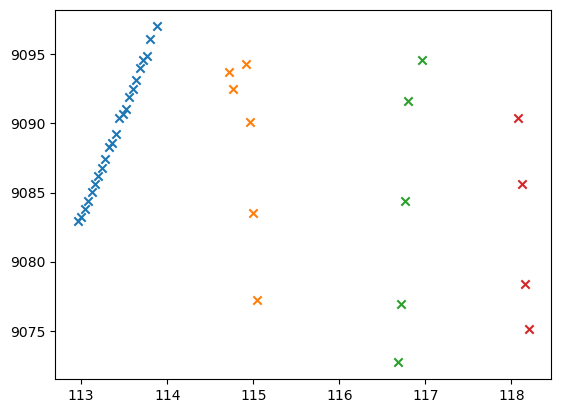

In [172]:
dP_split = 0.2
dE_del = 10
size_min = 4
sort = np.argsort(pitches)
pitch_sort = pitches[sort]
Eph_sort = Eph_seed[sort]

splitIdx = np.append(np.append([0],np.arange(1,pitch_sort.size)[np.diff(pitch_sort)>dP_split]),[pitch_sort.size])
#keep_idx = [np.ones(pH.size,dtype=bool) for pH in pitches_H]

pitches_H = [pitch_sort[splitIdx[idx]:splitIdx[idx+1]] for idx in range(splitIdx.size-1)]
E_H = [Eph_sort[splitIdx[idx]:splitIdx[idx+1]] for idx in range(splitIdx.size-1)]
del_bool_l = np.array([pline.size<size_min for pline in pitches_H])
for lidx in range(del_bool_l.size-1,0-1,-1):
    if del_bool_l[lidx]:
        del (pitches_H[lidx])
        del (E_H[lidx])
 
del_bool_l =np.array([False, False, True, False, True, False])
for lidx in range(del_bool_l.size-1,0-1,-1):
    if del_bool_l[lidx]:
        del (pitches_H[lidx])
        del (E_H[lidx])


for lidx in range(len(pitches_H)):
    dEH = np.diff(E_H[lidx])
    idx = np.hstack((True,dEH < dE_del))
    E_dummy = E_H[lidx][idx]
    pitches_dummy = pitches_H[lidx][idx]
    E_H[lidx] = E_dummy
    pitches_H[lidx] = pitches_dummy
    #plt.scatter(pitches_H[lidx],E_H[lidx],marker='x')

keep_idx = [np.ones(pH.size,dtype=bool) for pH in pitches_H]
keep_idx[0][-2:] = False
# keep_idx[1][-1] = False
# keep_idx[2][0:4] = False

for lidx in range(len(pitches_H)):
    pitches_H[lidx] = pitches_H[lidx][keep_idx[lidx]]
    E_H[lidx] = E_H[lidx][keep_idx[lidx]]
    plt.scatter(pitches_H[lidx],E_H[lidx],marker='x')

pitch_acc = pitches_H
E_H_acc = E_H
roll_acc = [roll for idx in range(len(pitch_acc))]


    

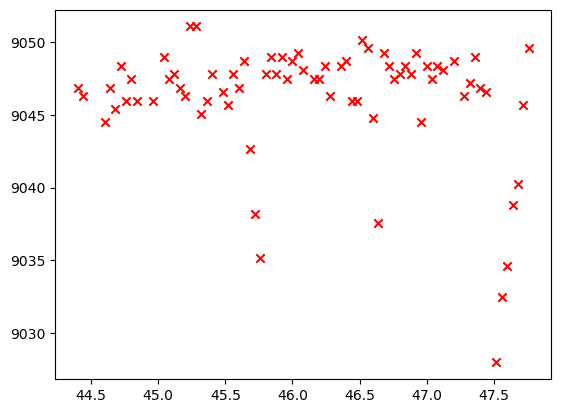

In [173]:
m = 35
pitches = pitch_dict[str(m)]
Eoffset_pre = 0#20
Eph_seed = np.array(seeding_energy_dict[str(m)])+Eoffset_pre
roll = roll_dict[str(m)]
plt.scatter(pitches,Eph_seed,marker='x',color='r')

In [174]:
bmir.cryst.yaw = np.deg2rad(dY)
Pitch = np.deg2rad(pitches)
PreSampling = bmir.BraggCurvesEvsAngles_inRange((Eph_seed.min()-20,Eph_seed.max()+20),PitchRange=[Pitch.min(),Pitch.max()],RollRange=np.deg2rad(roll+dR),numPreSampling=1000)
Hquery = PreSampling[1]
print(m, Hquery)
Hquery_acc = np.append(Hquery_acc,Hquery)
print(Hquery_acc)

35 [array([-3,  1,  1]) array([-3, -1, -1]) array([-1,  3, -3])]
[array([-1, -3,  1]) array([-3,  1, -1]) array([-1, -1,  3])
 array([-5, -1,  1]) array([-3,  1,  1]) array([-3, -1, -1])
 array([-1,  3, -3])]


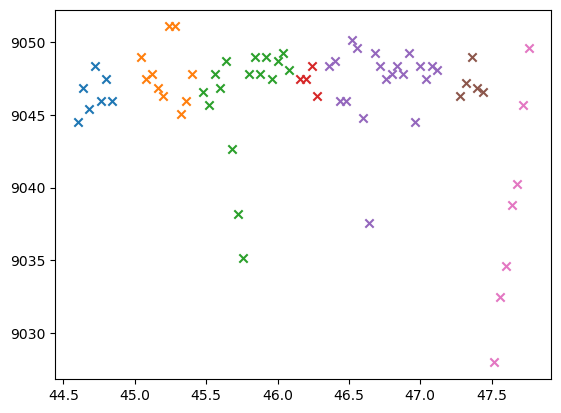

In [176]:
dP_split = 0.05
dE_del = 100
size_del = 4
sort = np.argsort(pitches)
pitch_sort = pitches[sort]
Eph_sort = Eph_seed[sort]

splitIdx = np.append(np.append([0],np.arange(1,pitch_sort.size)[np.diff(pitch_sort)>dP_split]),[pitch_sort.size])
pitches_H = [pitch_sort[splitIdx[idx]:splitIdx[idx+1]] for idx in range(splitIdx.size-1)]
E_H = [Eph_sort[splitIdx[idx]:splitIdx[idx+1]] for idx in range(splitIdx.size-1)]
del_bool_l = np.array([pline.size<size_del for pline in pitches_H])
for lidx in range(del_bool_l.size-1,0-1,-1):
    if del_bool_l[lidx]:
        del (pitches_H[lidx])
        del (E_H[lidx])
# del_bool_l = np.array([0,0,1,0])# 
# for lidx in range(del_bool_l.size-1,0-1,-1):
#     if del_bool_l[lidx]:
#         del (pitches_H[lidx])
#         del (E_H[lidx])
# select delete operation --> check if points are on line or rather cluster

#pitch_acc =+ pitches_H
#E_H_acc += E_H

keep_idx = [np.ones(pH.size,dtype=bool) for pH in pitches_H]
# keep_idx[1][0:4] = False
# keep_idx[1][-1] = False
# keep_idx[2][0:4] = False

for lidx in range(len(pitches_H)):
    pitches_H[lidx] = pitches_H[lidx][keep_idx[lidx]]
    E_H[lidx] = E_H[lidx][keep_idx[lidx]]
    plt.scatter(pitches_H[lidx],E_H[lidx],marker='x')

#plt.scatter(pitches_H[1][0:4],E_H[1][0:4],marker='x',color='tab:red')
#plt.scatter(pitches_H[1][-1],E_H[1][-1],marker='x',color='tab:red')
pitch_acc += pitches_H
E_H_acc += E_H
roll_acc += [roll for idx in range(len(pitch_acc))]

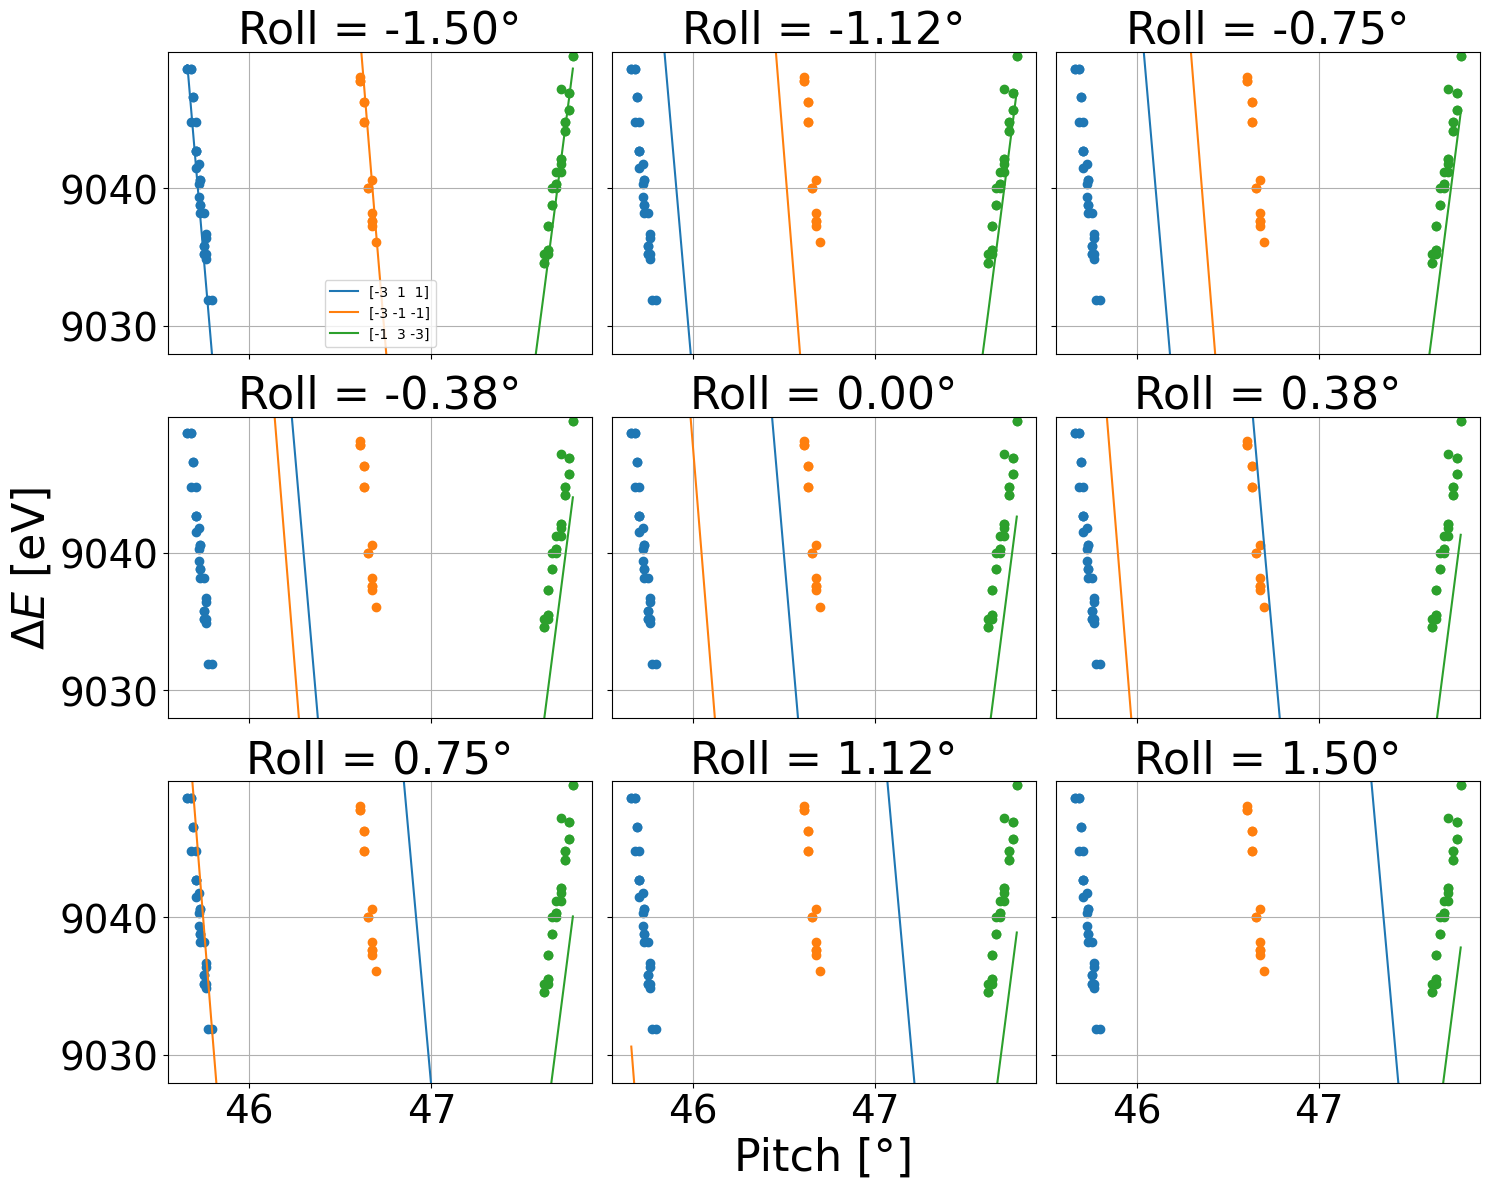

In [ ]:
Pitch = np.deg2rad(np.array([p for parray in pitches_H for p in parray]))

RollQuery = np.deg2rad(np.linspace(-1.5,1.5,9))
Yaw = np.deg2rad(dY)
bmir.cryst.yaw = Yaw
dPi = dP
Eoffset = -Ecorr
EBragg = np.zeros((RollQuery.size,Pitch.size,Hquery.size))
for Ridx, Roll in enumerate(RollQuery):
    bmir.cryst.roll = Roll+np.deg2rad(roll+dR)
    for Pidx,P in enumerate(Pitch):
        bmir.cryst.pitch = P+np.deg2rad(dPi)
        for Hidx,H in enumerate(Hquery):
            bmir.initialize()
            EBragg[Ridx,Pidx,Hidx] = bmir.bragg_wavelength(H=H)[1]-Eoffset

# now parse 
fig_parse, axs = plt.subplots(nrows=3,ncols=3,tight_layout=True,figsize=(15,12))
ylims = np.array([Eph_seed.min(),Eph_seed.max()])
#ylims = [-0.25,0.25]
for idx, ax in enumerate(axs.flatten()):
    #Ridx = idx*int((Roll.size-1)/8)
    ax.tick_params(labelsize=28)
    ax.grid()
    ax.set_title("Roll = {:.2f}°".format(np.rad2deg(RollQuery[idx])),fontsize=32)
    if idx%3>0:
        ax.tick_params(labelleft=False)
    if idx<6:
        ax.tick_params(labelbottom=False)
        #ax.set_xlabel("$\\Delta E$[meV]",fontsize=32)
    for lidx, peval in enumerate(pitches_H):
        ax.scatter(peval,E_H[lidx])
    for Hidx in range(Hquery.shape[0]):
        
        ax.plot(np.rad2deg(Pitch),EBragg[idx,:,Hidx].squeeze(),label=str(Hquery[Hidx]))
        #ax.fill_between((Pitch-np.pi/2)*1E3,(E_Hs[Ridx,:,Hidx]*(1+bw_Hs[Ridx,:,Hidx,0])).squeeze()-bmir.E_c,(E_Hs[Ridx,:,Hidx]*(1+bw_Hs[Ridx,:,Hidx,1])).squeeze()-bmir.E_c)

    ax.set_ylim(ylims)
    #ax.set_xlim((Pitch[0]-np.pi/2)*1E3,(Pitch[-1]-np.pi/2)*1E3)
axs[2,1].set_xlabel("Pitch [°]",fontsize=32)
axs[1,0].set_ylabel("$\\Delta E$ [eV]",fontsize=32)
axs[0,0].legend()

In [ ]:
dPi,dRi,dYi,Ecorr = [-1.36620953,  1.29531582-1.5,  2.20385814, -1.22391416-Eoffset_pre]  #res.x
HtoMeas = HtoMeasf_acc(pitches_H,[roll for idx in range(len(pitches_H))],E_H,Hquery,dPi,dRi,dYi,Ecorr)
print(HtoMeas)
for Hidx, H in enumerate(Hquery):
    lidx = HtoMeas[Hidx]
    # print(lidxi
    # P0 = P0s[lidx]
    peval = pitches_H[lidx]
    
    #dP, dR, Ecorr = res.x

    EBragg = getBragg(np.deg2rad(peval+dPi), np.deg2rad(roll+dRi), np.deg2rad(dYi), H)
    plt.scatter(pitches_H[lidx],E_H[lidx])
    plt.plot(peval, EBragg)

TypeError: HtoMeasf_acc() missing 1 required positional argument: 'Ecorr'

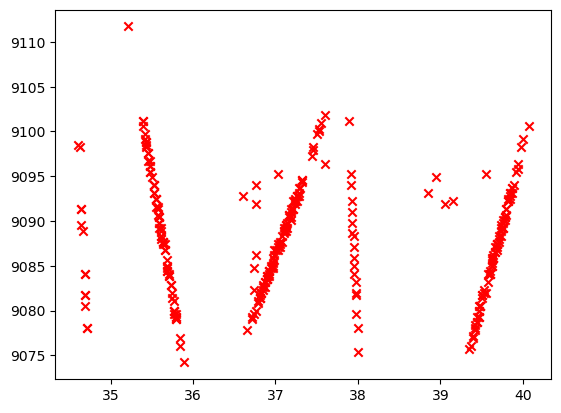

In [ ]:
m = 6
pitches = pitch_dict[str(m)]
Eoffset_pre = 0#20
Eph_seed = np.array(seeding_energy_dict[str(m)])+Eoffset_pre
roll = roll_dict[str(m)]
plt.scatter(pitches,Eph_seed,marker='x',color='r')

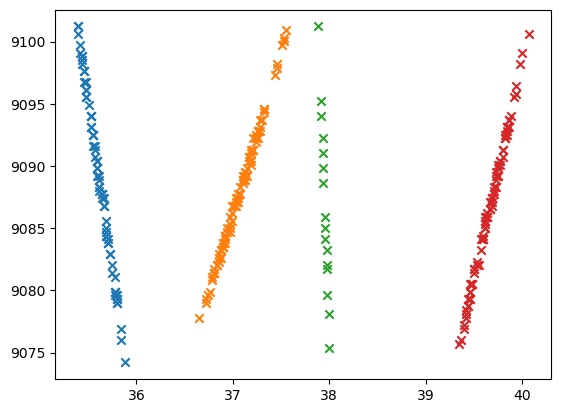

In [ ]:
dP_split = 0.1
dE_del = 2

sort = np.argsort(pitches)
pitch_sort = pitches[sort]
Eph_sort = Eph_seed[sort]

splitIdx = np.append(np.append([0],np.arange(1,pitch_sort.size)[np.diff(pitch_sort)>dP_split]),[pitch_sort.size])
pitches_H = [pitch_sort[splitIdx[idx]:splitIdx[idx+1]] for idx in range(splitIdx.size-1)]
E_H = [Eph_sort[splitIdx[idx]:splitIdx[idx+1]] for idx in range(splitIdx.size-1)]
del_bool_l = np.array([pline.size<8 for pline in pitches_H])
for lidx in range(del_bool_l.size-1,-1,-1):
    if del_bool_l[lidx]:
        del (pitches_H[lidx])
        del (E_H[lidx])

for lidx in range(len(pitches_H)):
    dEH = np.diff(E_H[lidx])
    idx = np.hstack((True,dEH < dE_del))
    while any(np.logical_not(idx)):
        E_dummy = E_H[lidx][idx]
        pitches_dummy = pitches_H[lidx][idx]
        E_H[lidx] = E_dummy
        pitches_H[lidx] = pitches_dummy
        dEH = np.diff(E_H[lidx])
        idx = np.hstack((True,dEH < dE_del))
# del_bool_l = np.array([0,0,1,0])# 
# for lidx in range(del_bool_l.size-1,0-1,-1):
#     if del_bool_l[lidx]:
#         del (pitches_H[lidx])
#         del (E_H[lidx])
# select delete operation --> check if points are on line or rather cluster

#pitch_acc =+ pitches_H
#E_H_acc += E_H
del pitches_H[0]
del E_H[0]

pitches_H = [pitches_H[0], np.append(pitches_H[1],pitches_H[2]),pitches_H[3],pitches_H[4]]
E_H = [E_H[0], np.append(E_H[1],E_H[2]),E_H[3],E_H[4]]


keep_idx = [np.ones(pH.size,dtype=bool) for pH in pitches_H]
keep_idx[1][0] = False
keep_idx[1][-1] = False
# keep_idx[2][0:4] = False

for lidx in range(len(pitches_H)):
    pitches_H[lidx] = pitches_H[lidx][keep_idx[lidx]]
    E_H[lidx] = E_H[lidx][keep_idx[lidx]]
    plt.scatter(pitches_H[lidx],E_H[lidx],marker='x')

#plt.scatter(pitches_H[1][-1],E_H[1][-1],marker='x',color='tab:purple')
#plt.scatter(pitches_H[1][-1],E_H[1][-1],marker='x',color='tab:red')
pitch_acc += pitches_H
E_H_acc += E_H
roll_acc += [roll for idx in range(len(pitch_acc))]

In [ ]:
bmir.cryst.yaw = np.deg2rad(dYconv)
Pitch = np.deg2rad(pitches+dPconv)
PreSampling = bmir.BraggCurvesEvsAngles_inRange((Eph_seed.min()-20,Eph_seed.max()+20),PitchRange=[Pitch.min(),Pitch.max()],RollRange=np.deg2rad(roll+dRconv)+dRPconv*np.abs(np.pi/2-Pitch.mean()),numPreSampling=1000)
Hquery = PreSampling[1]
print(m, Hquery)
#delete [-1, -1,  1] line, as it is hard to discern
Hquery = np.delete(Hquery,1)
print(m, Hquery)
Hquery_acc = np.append(Hquery_acc,Hquery)
print(Hquery_acc)

6 [array([-1, -1, -1]) array([-1, -1,  1]) array([-2,  2, -4])
 array([-2,  4, -2]) array([-4,  2, -2])]
6 [array([-1, -1, -1]) array([-2,  2, -4]) array([-2,  4, -2])
 array([-4,  2, -2])]
[array([-1, -3,  1]) array([-3,  1, -1]) array([-1, -1,  3])
 array([-5, -1,  1]) array([-3,  1,  1]) array([-3, -1, -1])
 array([-1,  3, -3]) array([-1, -1, -1]) array([-2,  2, -4])
 array([-2,  4, -2]) array([-4,  2, -2])]


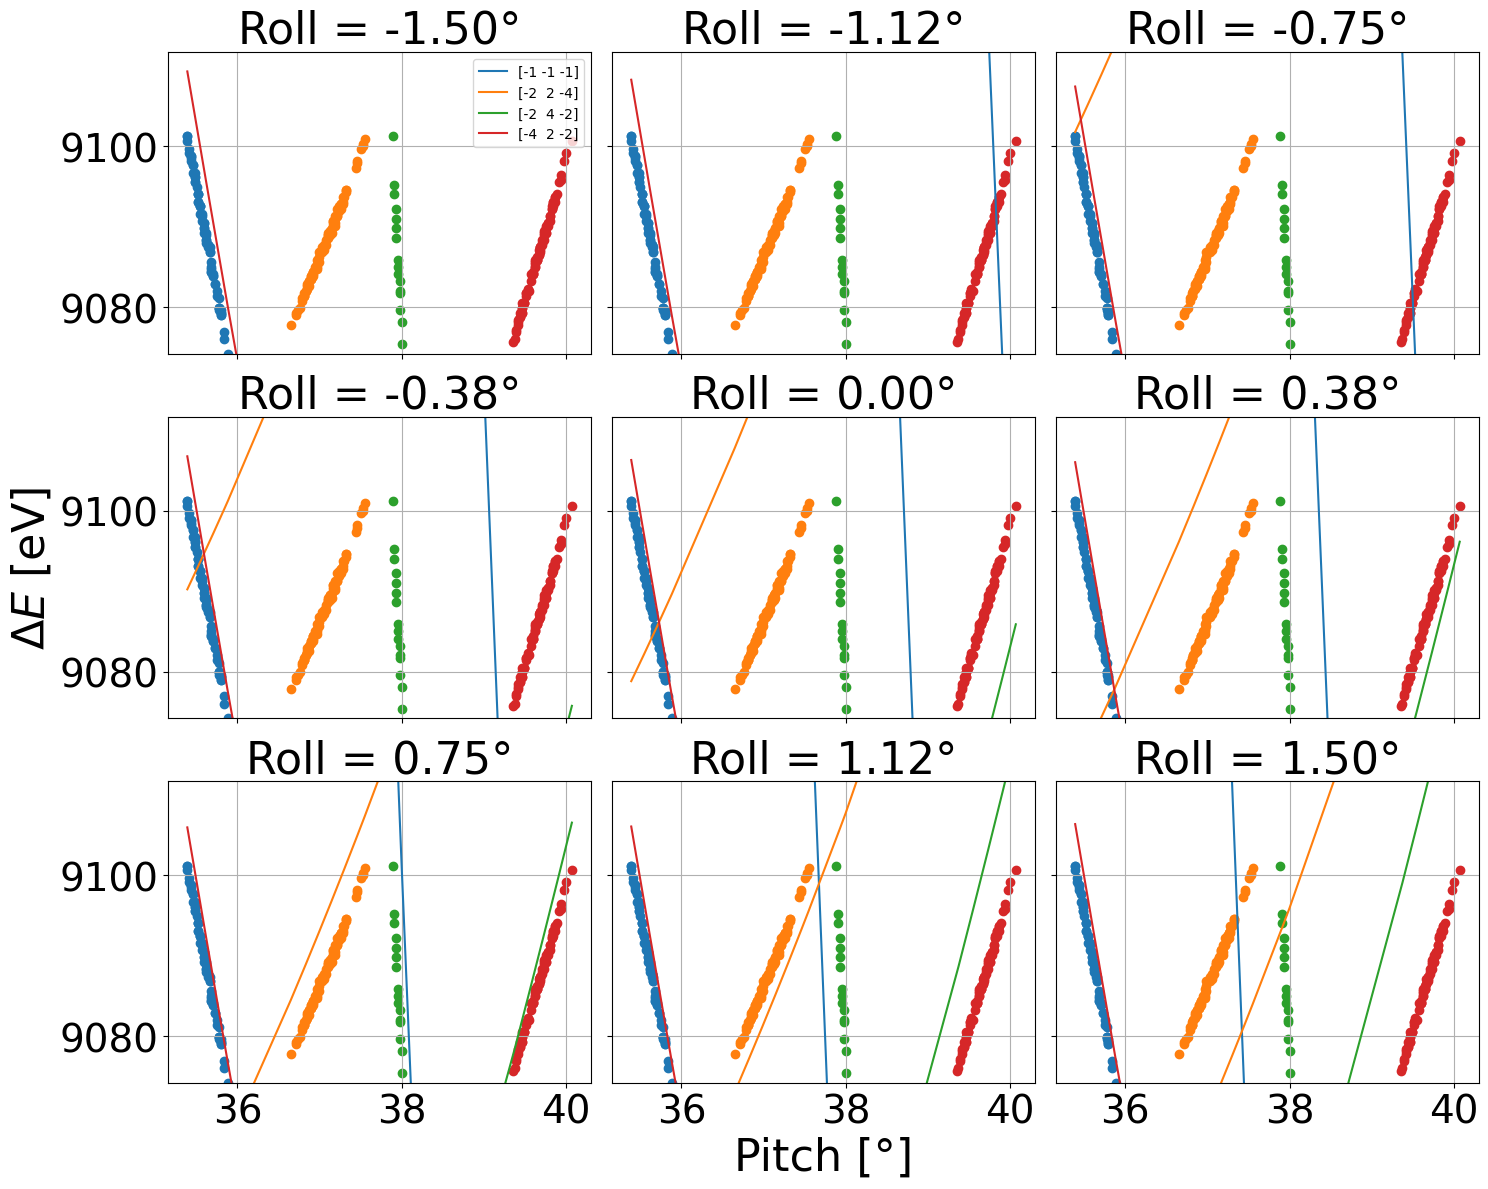

In [ ]:
Pitch = np.deg2rad(np.array([p for parray in pitches_H for p in parray]))

RollQuery = np.deg2rad(np.linspace(-1.5,1.5,9))
Yaw = np.deg2rad(dYconv)
#bmir.cryst.yaw = Yaw
#dPi = dP
Eoffset = Ecorr
# EBragg = np.zeros((RollQuery.size,Pitch.size,Hquery.size))
# for Ridx, Roll in enumerate(RollQuery):
#     bmir.cryst.roll = Roll+np.deg2rad(roll+dRconv)
#     for Pidx,P in enumerate(Pitch):
#         bmir.cryst.pitch = P+np.deg2rad(dPconv)
#         bmir.cryst.roll += dRPconv*np.abs(np.pi/2-bmir.cryst.pitch)
#         for Hidx,H in enumerate(Hquery):
#             bmir.initialize()
#             EBragg[Ridx,Pidx,Hidx] = bmir.bragg_wavelength(H=H)[1]-Eoffset

# now parse 
fig_parse, axs = plt.subplots(nrows=3,ncols=3,tight_layout=True,figsize=(15,12))
ylims = np.array([Eph_seed.min(),Eph_seed.max()])
#ylims = [-0.25,0.25]
for idx, ax in enumerate(axs.flatten()):
    #Ridx = idx*int((Roll.size-1)/8)
    ax.tick_params(labelsize=28)
    ax.grid()
    ax.set_title("Roll = {:.2f}°".format(np.rad2deg(RollQuery[idx])),fontsize=32)
    if idx%3>0:
        ax.tick_params(labelleft=False)
    if idx<6:
        ax.tick_params(labelbottom=False)
        #ax.set_xlabel("$\\Delta E$[meV]",fontsize=32)
    for lidx, peval in enumerate(pitches_H):
        ax.scatter(peval,E_H[lidx])
    for Hidx in range(Hquery.shape[0]):
        EBragg = getBragg_wPRcorr(Pitch+np.deg2rad(dPconv),RollQuery[idx]+np.deg2rad(roll+dRconv),np.deg2rad(dYconv),dRPconv,Hquery[Hidx])+Ecorr
        ax.plot(np.rad2deg(Pitch),EBragg,label=str(Hquery[Hidx]))
        #ax.fill_between((Pitch-np.pi/2)*1E3,(E_Hs[Ridx,:,Hidx]*(1+bw_Hs[Ridx,:,Hidx,0])).squeeze()-bmir.E_c,(E_Hs[Ridx,:,Hidx]*(1+bw_Hs[Ridx,:,Hidx,1])).squeeze()-bmir.E_c)

    ax.set_ylim(ylims)
    #ax.set_xlim((Pitch[0]-np.pi/2)*1E3,(Pitch[-1]-np.pi/2)*1E3)
axs[2,1].set_xlabel("Pitch [°]",fontsize=32)
axs[1,0].set_ylabel("$\\Delta E$ [eV]",fontsize=32)
axs[0,0].legend()

In [ ]:
dRP_guess = 1.5/(np.abs(90-116)-np.abs(90-46.5))
dR0_guess = dR-np.abs(90-116)*dRP_guess
print(dRP_guess,dR0_guess)

-0.08571428571428572 3.5238872485714285


[1, 2, 3, 0, 4, 5, 6, 9, 8, 10, 7]


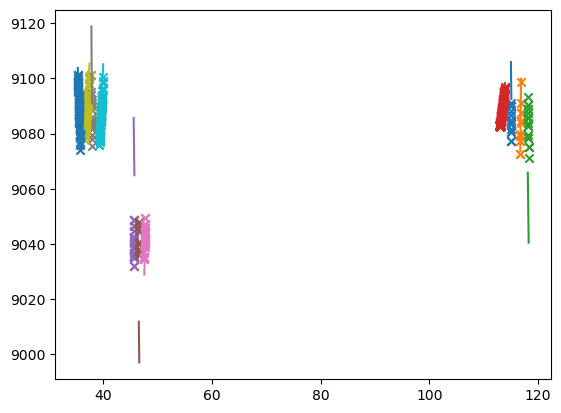

In [ ]:
dPi,dRi,dYi,dPRi,Ecorr = [-1.36350551,  2.03498349,  2.68730152,-0.03816467,  1.3590789 -Eoffset_pre]  #res.x
#HtoMeas = HtoMeasf_acc(pitch_acc,roll_acc,E_H_acc,Hquery_acc,dPi,dRi,dPRi,dYi,Ecorr)
HtoMeas = [ 1,  2,  3,  0,  4,  5,  6, 9, 8, 10,  7] #corrected H to meas:
print(HtoMeas)
for Hidx, H in enumerate(Hquery_acc):
    lidx = HtoMeas[Hidx]
    # print(lidx)
    # P0 = P0s[lidx]
    peval = pitch_acc[lidx]
    
    #dP, dR, Ecorr = res.x

    EBragg = getBragg_wPRcorr(np.deg2rad(peval+dPi), np.deg2rad(roll_acc[lidx]+dRi), np.deg2rad(dY),dPRi, H)
    plt.plot(peval, EBragg)
    plt.scatter(peval,E_H_acc[lidx],marker='x')




### Do the actual fit

1
[-1.40719582  3.62960387  2.26997388 -0.07714286  1.39985127] 1917.0422925440496


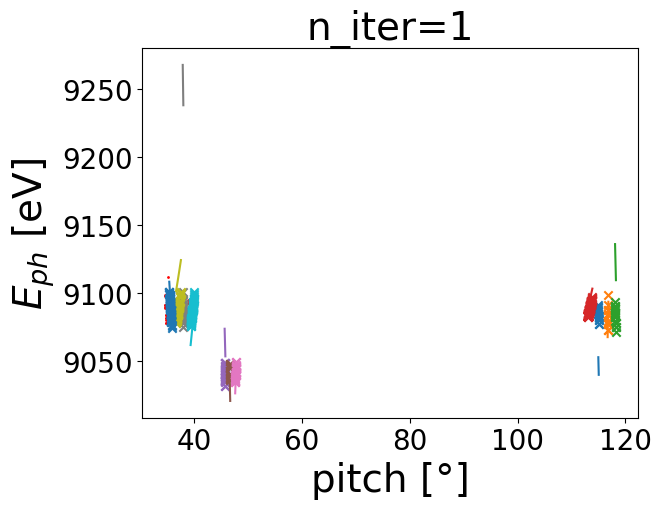

51
[-1.41251961  3.26248248  1.77670962 -0.07120293  1.66773505] 242.5232938883111


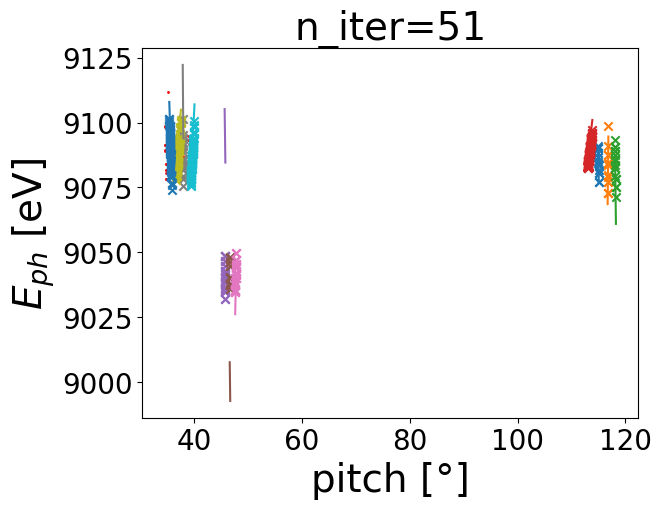

101
[-1.22484289 -2.67955053  4.58322251  0.11105223  1.11637584] 63.132911499190115


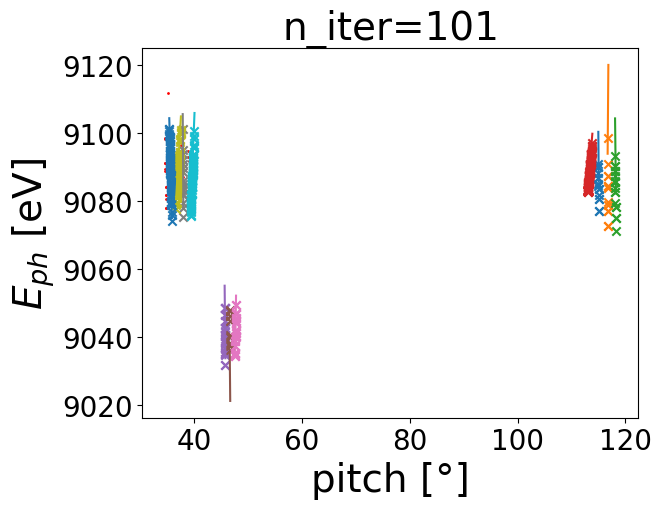

151
[-1.2587885  -2.18970099  4.33415182  0.0957027   1.14486152] 56.699402296445655


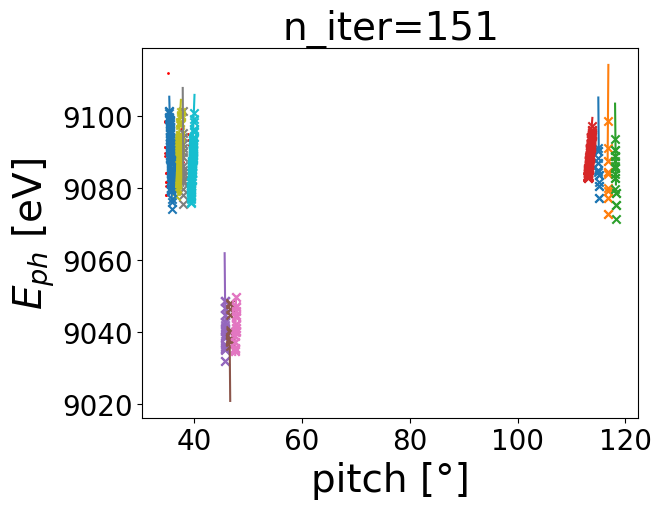

201
[-1.25567758 -3.42338723  4.88826083  0.13321996 -9.89794514] 30.810316429704905


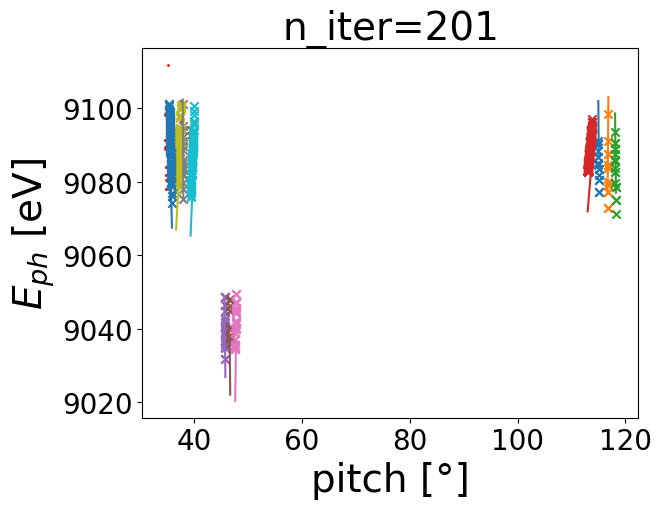

251
[-1.24526382 -3.56551731  4.96930094  0.13773002 -9.60107214] 29.69198282373605


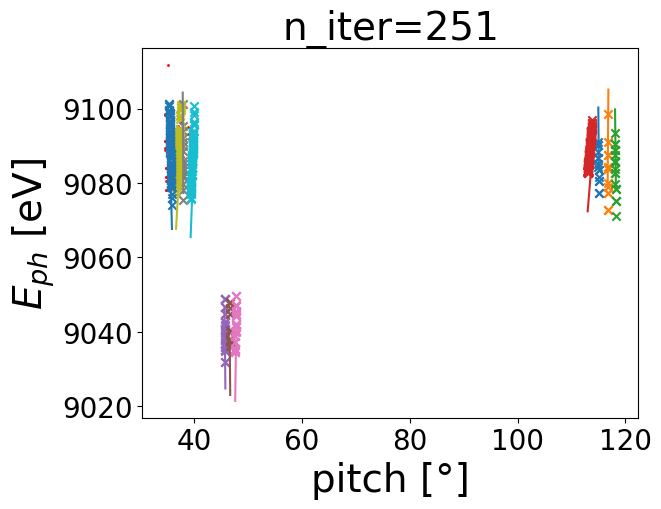

301
[-1.24519209 -3.56692702  4.96993902  0.13777121 -9.59774567] 29.69192243429928


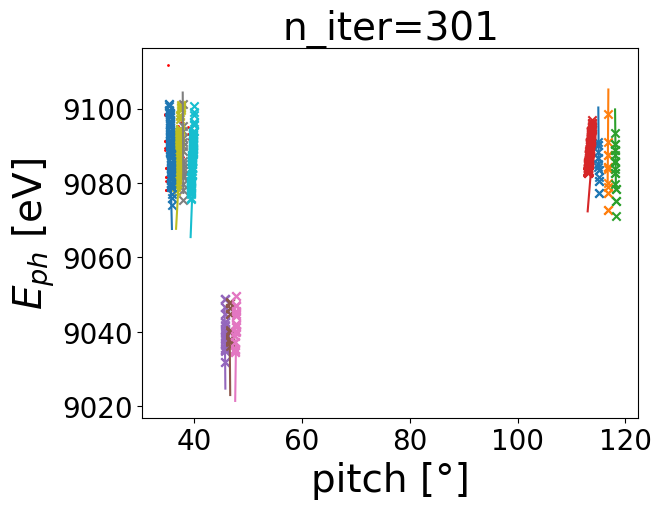

351
[-1.24519255 -3.56692592  4.9699382   0.13777116 -9.59788328] 29.69192242589693


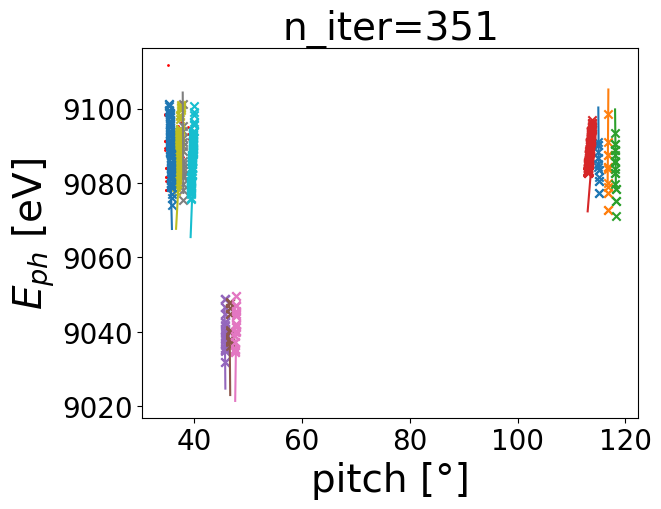

401
[-1.24519256 -3.56692556  4.96993804  0.13777115 -9.59788256] 29.691922425889253


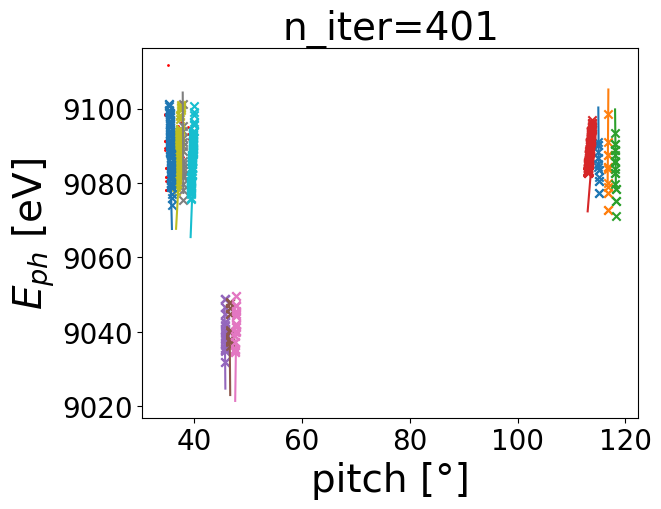

451
[-1.24519256 -3.56692556  4.96993804  0.13777115 -9.59788256] 29.69192242588925


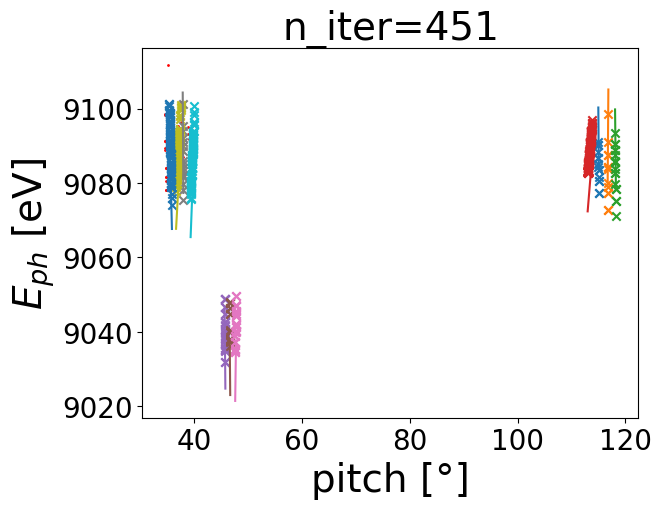

501
[-1.24519256 -3.56692556  4.96993804  0.13777115 -9.59788256] 29.691922425888546


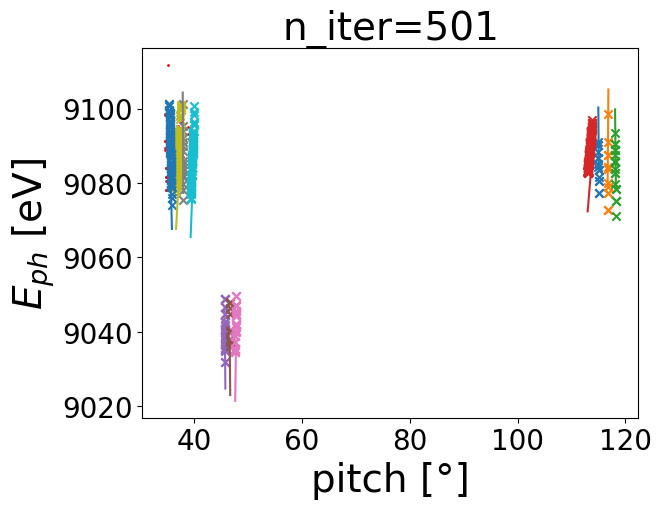

551
[-1.24519256 -3.56692556  4.96993804  0.13777115 -9.59788256] 29.691922425888546


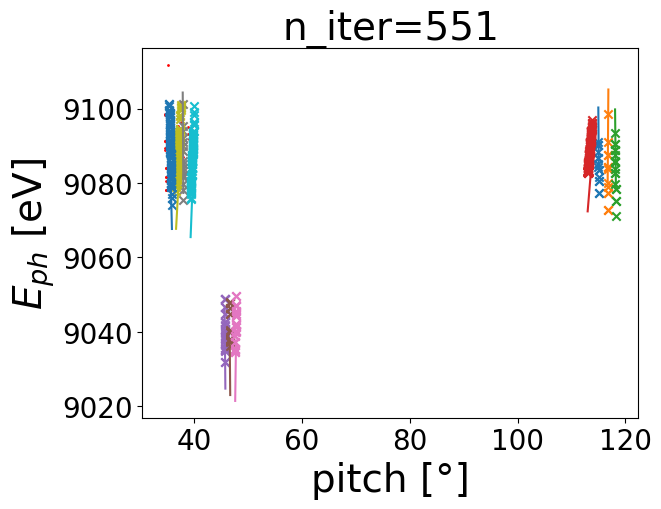

601
[-1.24519256 -3.56692556  4.96993804  0.13777115 -9.59788256] 29.691922425888546


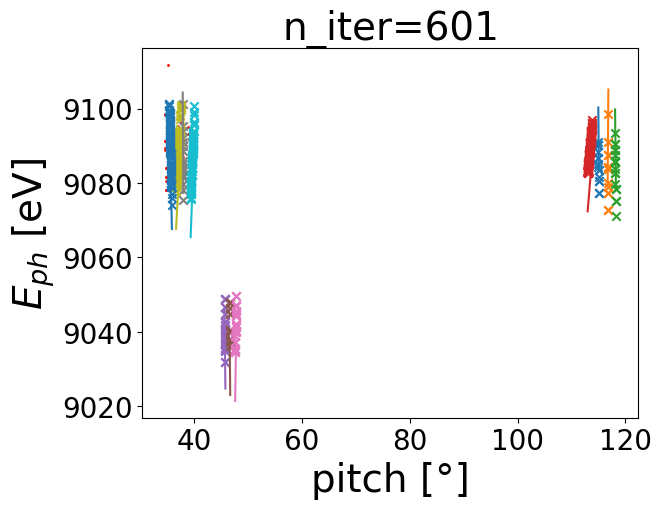

651
[-1.24519256 -3.56692556  4.96993804  0.13777115 -9.59788256] 29.691922425888546


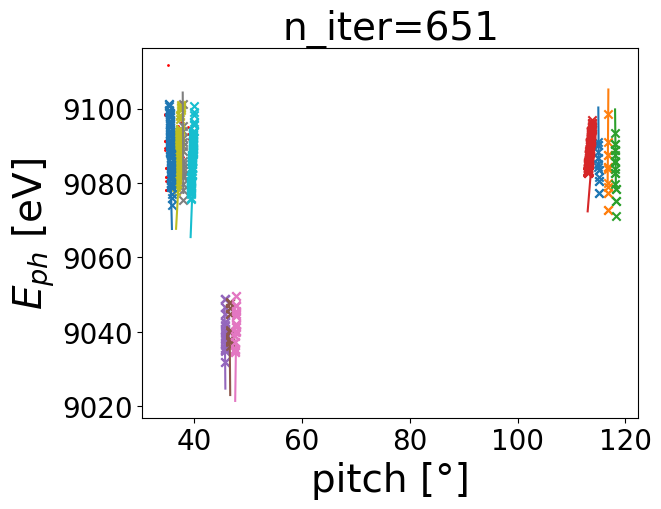

701
[-1.24519256 -3.56692556  4.96993804  0.13777115 -9.59788256] 29.691922425888546


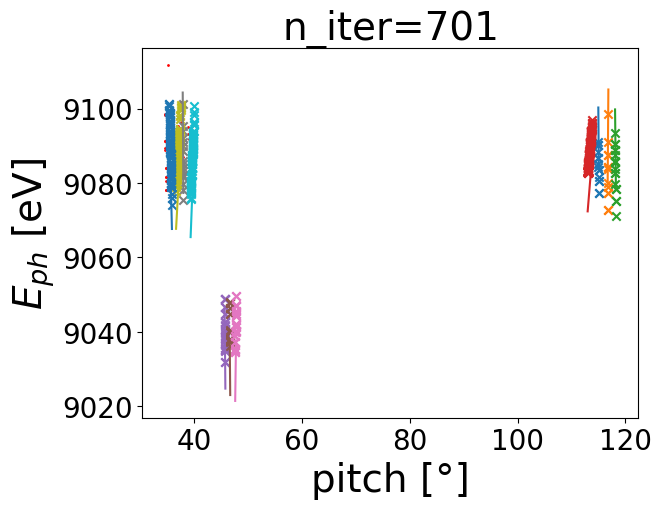

751
[-1.24519256 -3.56692556  4.96993804  0.13777115 -9.59788256] 29.691922425888546


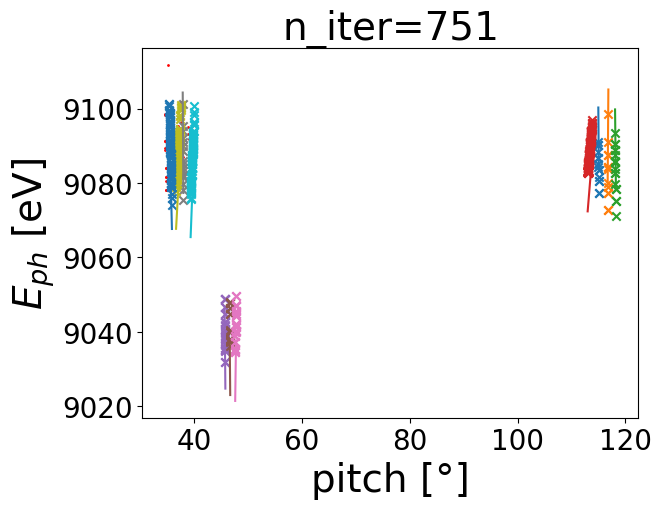

801
[-1.24519256 -3.56692556  4.96993804  0.13777115 -9.59788256] 29.691922425888546


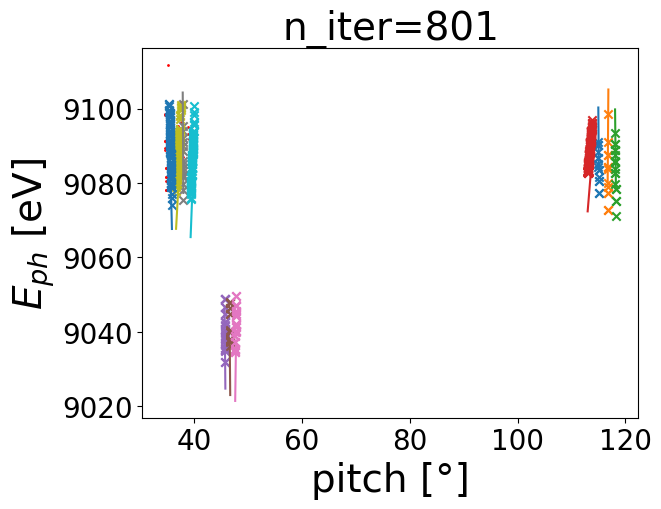

851
[-1.24519256 -3.56692556  4.96993804  0.13777115 -9.59788256] 29.691922425888546


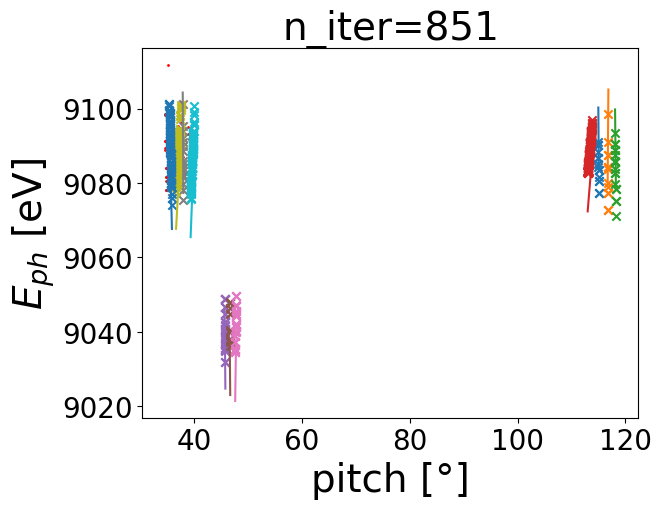

901
[-1.24519256 -3.56692556  4.96993804  0.13777115 -9.59788256] 29.691922425888546


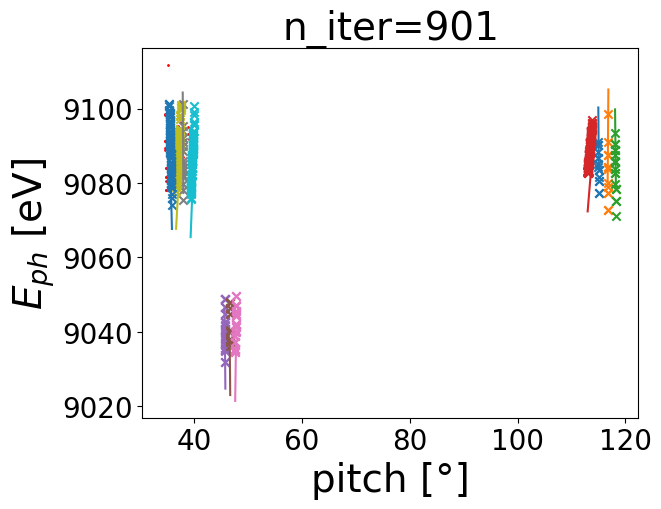

951
[-1.24519256 -3.56692556  4.96993804  0.13777115 -9.59788256] 29.691922425888546


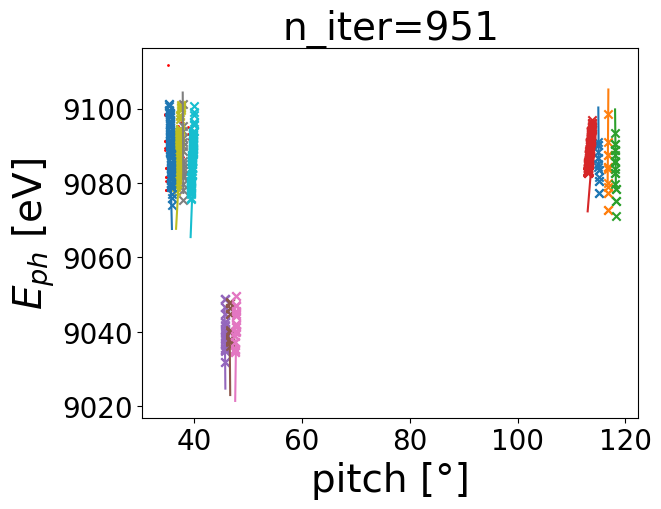

/tmp/ipykernel_572680/3361373616.py:47: RuntimeWarning:

Maximum number of iterations has been exceeded.



1000
[-1.24519256 -3.56692556  4.96993804  0.13777115 -9.59788256] 29.691922425888546


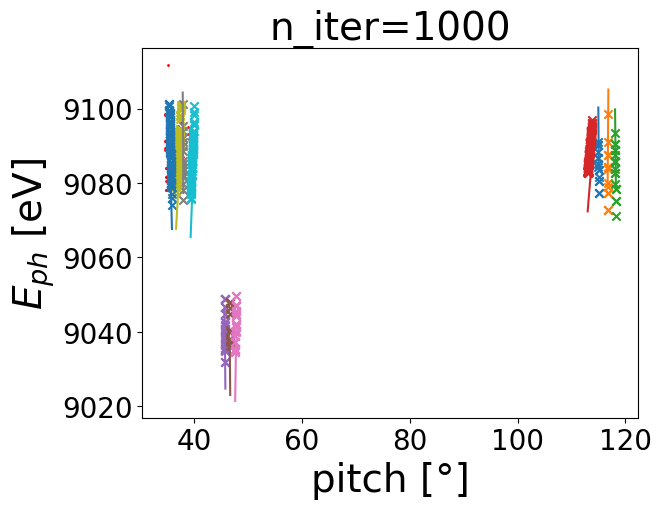

In [ ]:
#do the actual fit
def optFuncp_wdPR(dP,dR,dY,dPR,Ecorr):
    #peval = np.linspace(pitches.min(),pitches.max(),3001)
    cost = 0

    for Hidx, H in enumerate(Hquery_acc):
        lidx = HtoMeas[Hidx]
        peval = pitch_acc[lidx]
        EBraggs = getBragg_wPRcorr(np.deg2rad(peval+dP),np.deg2rad(roll_acc[lidx]+dR),np.deg2rad(dY),dPR,H)+Ecorr
        cost += np.sum((EBraggs-E_H_acc[lidx])**2)/peval.size**2

    return 1/cost
def optFunc_minimizer(x):
    #return 1/optFuncp(x[0],x[1],x[2],0)
    return 1/optFuncp_wdPR(x[0],x[1],x[2],x[3],x[4])
def display_Func(intermediate_result):
    global forcePlot
    global niter
    niter += 1
    if(niter%50 == 1 or forcePlot):
        print(niter)
        print(intermediate_result.x,intermediate_result.fun)
        plt.title("n_iter="+str(niter),fontsize=28)
        plt.scatter(pitches,Eph_seed,color='red',s=1)
        plt.ylabel("$E_{ph}$ [eV]",fontsize=28)
        plt.xlabel("pitch [°]", fontsize=28)
        plt.tick_params(labelsize=20)
        dP,dR,dY,dPR,Ecorr = intermediate_result.x
        #dP,dR,dY = intermediate_result.x
        for Hidx, H in enumerate(Hquery_acc):
            lidx = HtoMeas[Hidx]
            #print(lidx)
            #P0 = P0s[lidx]
            peval = pitch_acc[lidx]
            EBragg = getBragg_wPRcorr(np.deg2rad(peval+dP),np.deg2rad(roll_acc[lidx]+dR),np.deg2rad(dY),dPR,H)+Ecorr

            #print(peval_sub.min(),peval_sub.max())
            plt.scatter(peval,E_H_acc[lidx],marker='x')
            plt.plot(peval,EBragg)
            #plt.ylim(Eph_seed.min(),Eph_seed.max())
        plt.show()

niter = 0
forcePlot = False
x0 = np.array([dP, dR0_guess, dY, dRP_guess, Ecorr])
bounds = ([-3,3],[-5,5],[-10,10],[-0.2,0.2],[-50,50])
res = opt.minimize(optFunc_minimizer, x0, method='Nelder-Mead',
               options={'xatol': 1e-14,'fatol': 1e-14, 'disp': True,'maxiter':1000},bounds=bounds,callback=display_Func)
forcePlot=True
display_Func(res)
dPconv,dRconv,dYconv,dRP_conv,Ecorr_conv = res.x

In [ ]:
dPconv,dRconv,dYconv,dRPconv,Ecorrconv =res.x# [-1.36350551,  2.03498349,  2.68730152 -0.03816467,  1.3590789 ]#

In [ ]:
f"{roll:.2f}"

'1.28'

### use the fit parameters for the other measurements --> not really good

0 Roll = 1.28°


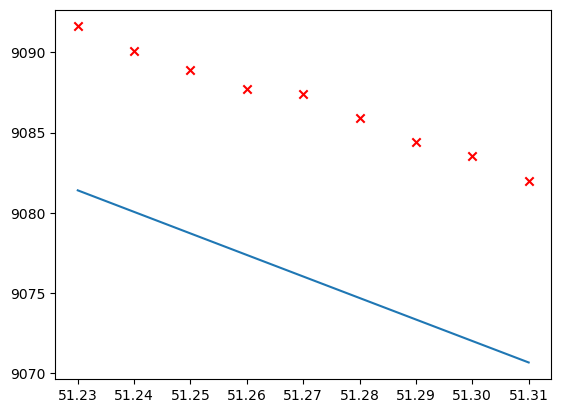

1 Roll = 1.28°


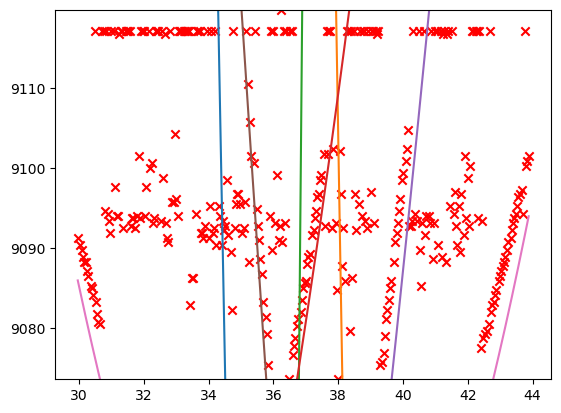

2 Roll = 1.28°


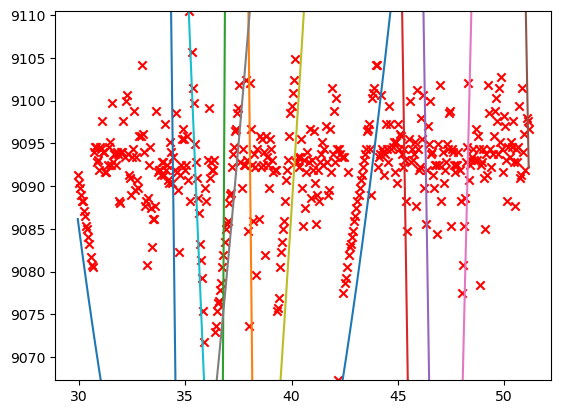

3 Roll = 1.28°


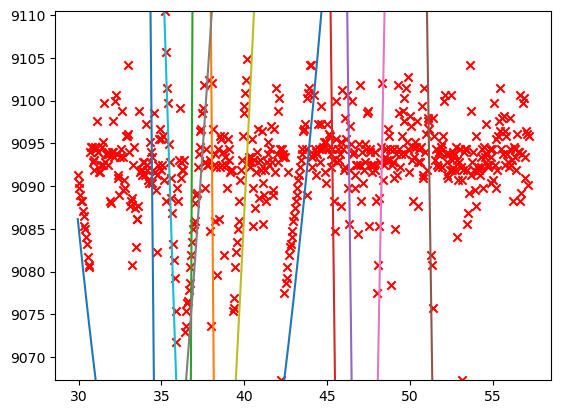

4 Roll = 1.28°


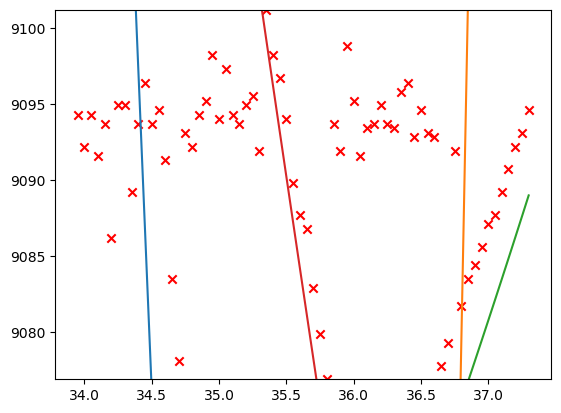

5 Roll = 1.28°


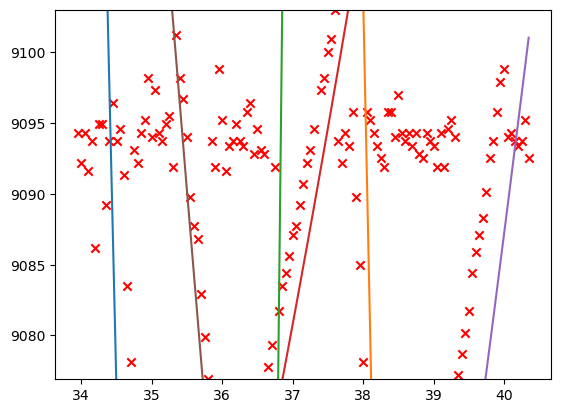

6 Roll = 1.28°


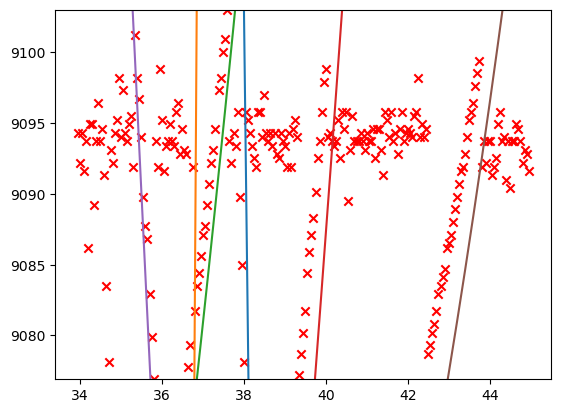

7 Roll = 1.28°


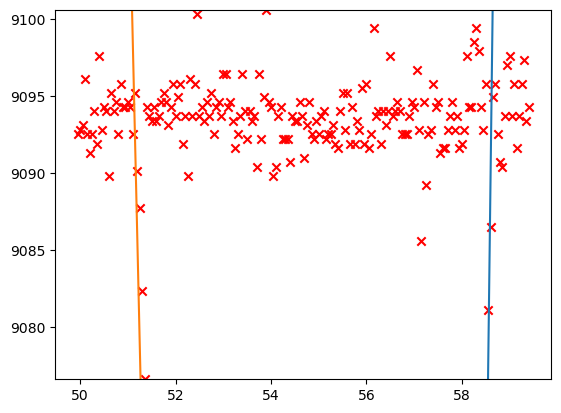

8 Roll = 1.28°


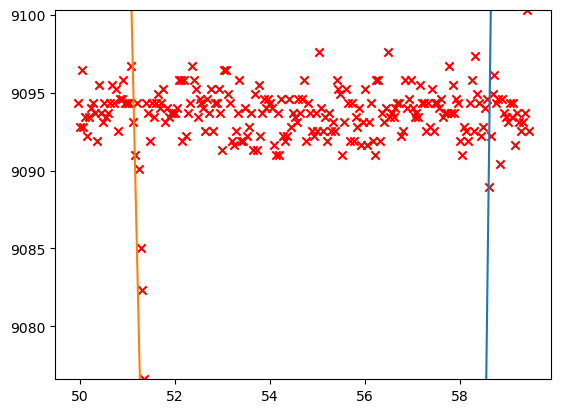

9 Roll = 1.28°


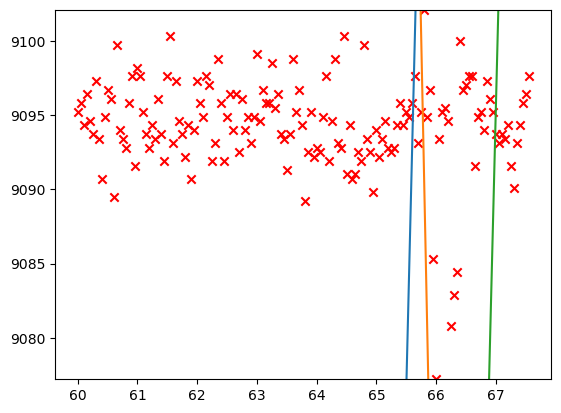

10 Roll = 1.28°


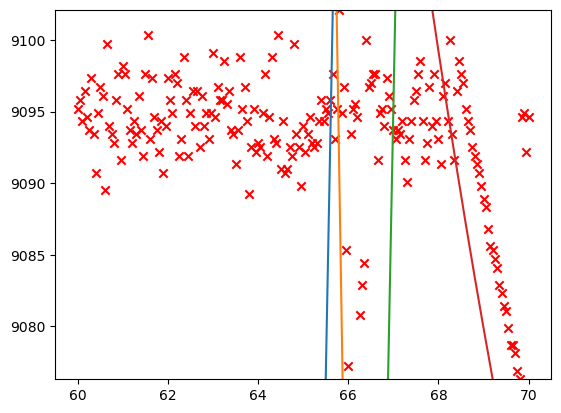

11 Roll = 1.28°


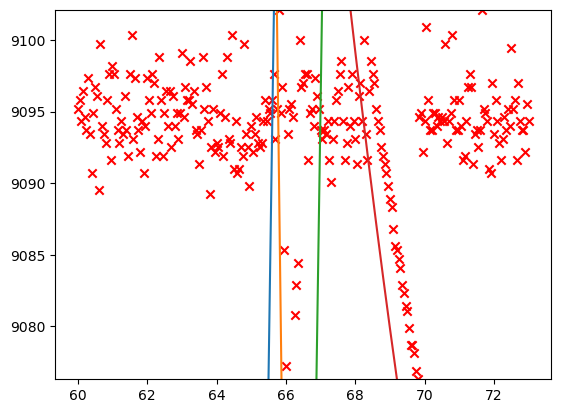

12 Roll = 0.28°


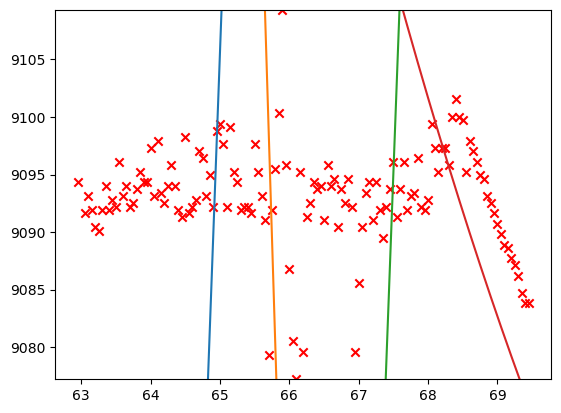

13 Roll = 0.28°


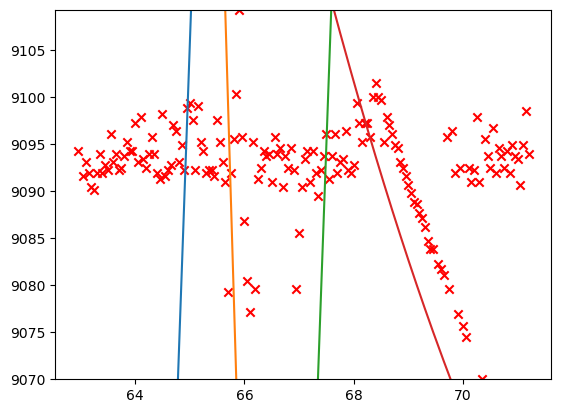

14 Roll = 1.28°


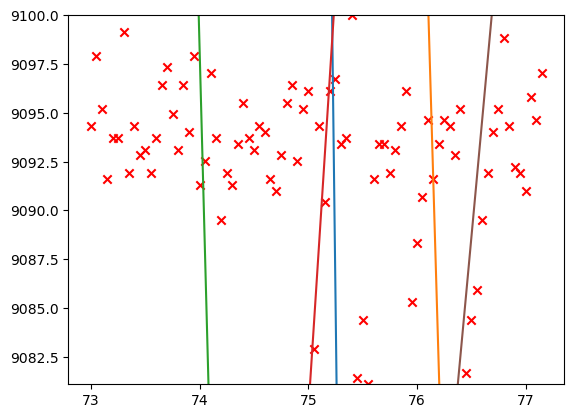

15 Roll = 1.28°


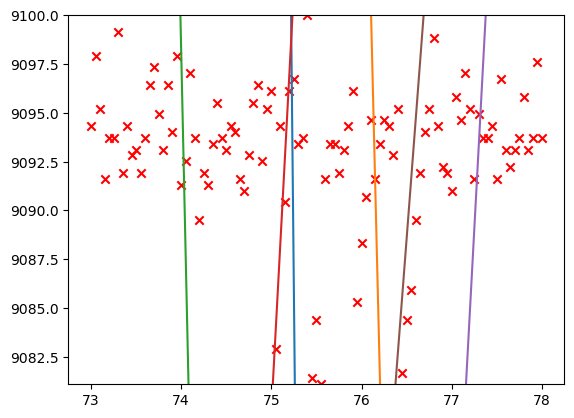

16 Roll = 1.28°


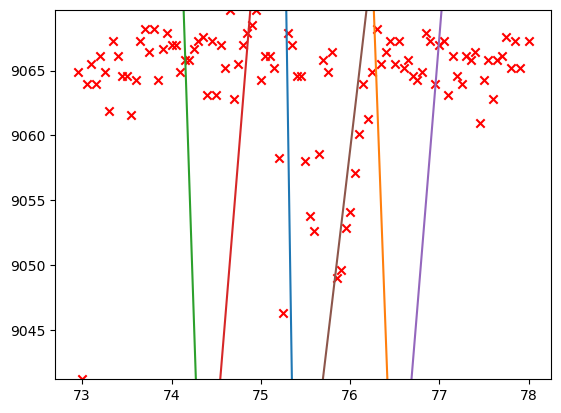

17 Roll = 1.28°


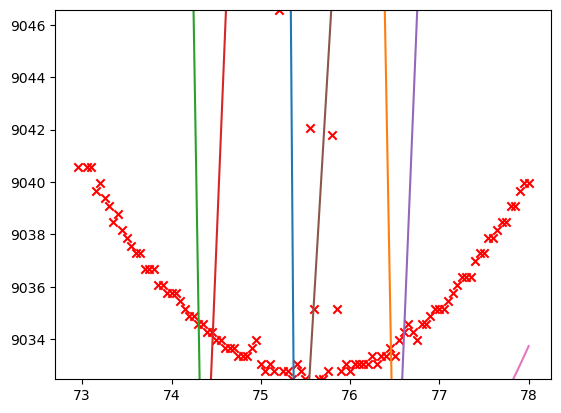

18 Roll = 0.28°


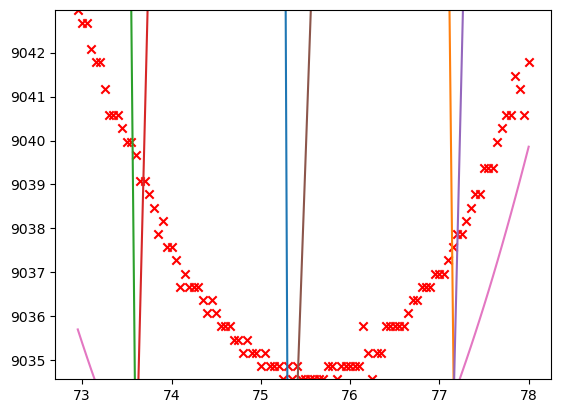

19 Roll = 0.28°


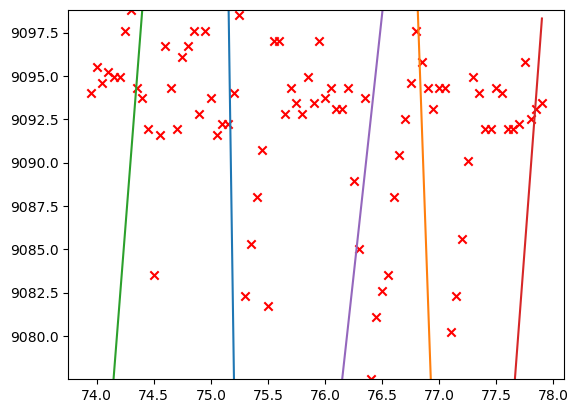

20 Roll = 0.28°


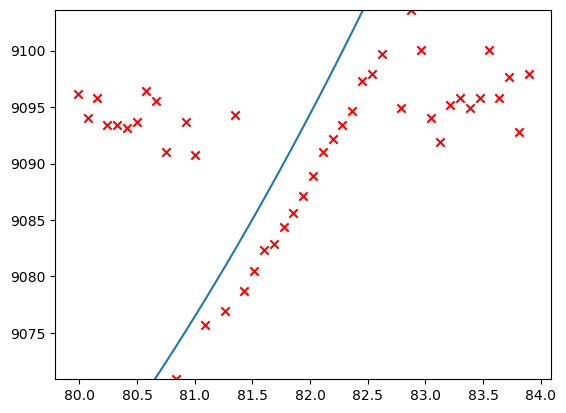

21 Roll = 1.28°


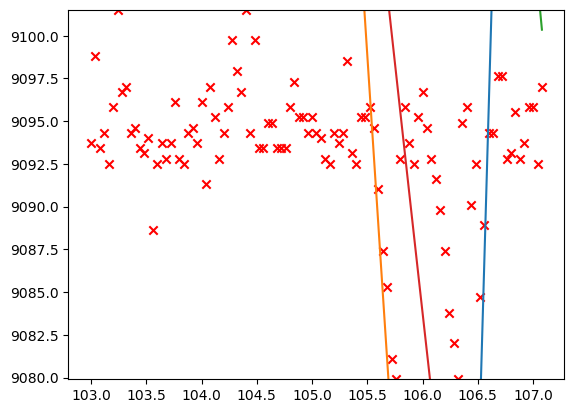

22 Roll = 1.28°


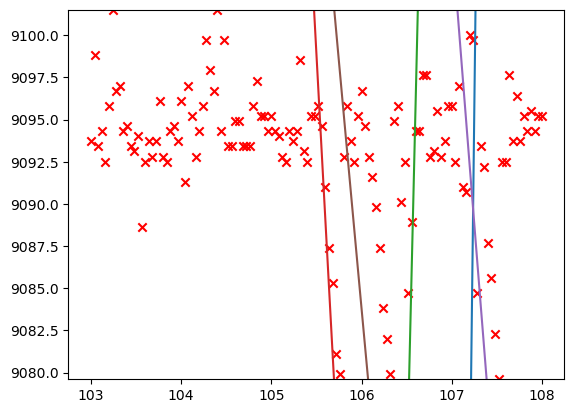

23 Roll = 0.28°


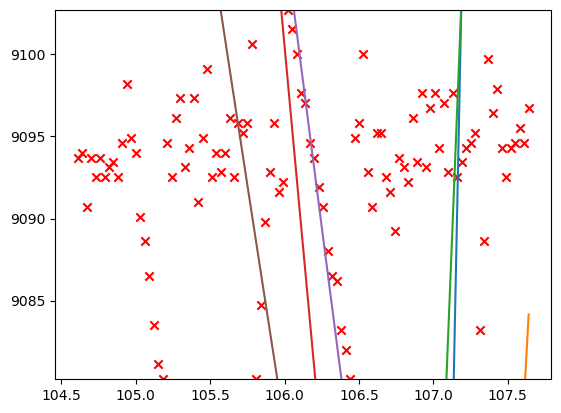

24 Roll = 1.28°


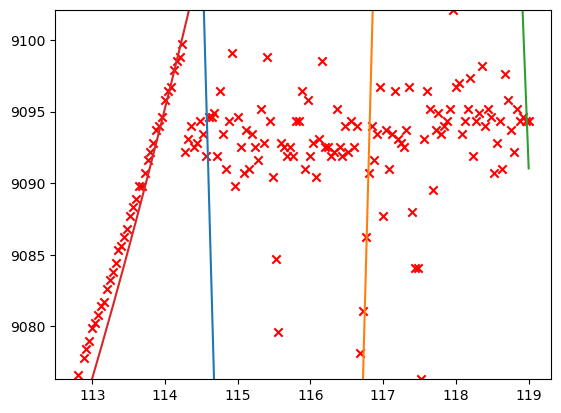

25 Roll = 0.28°


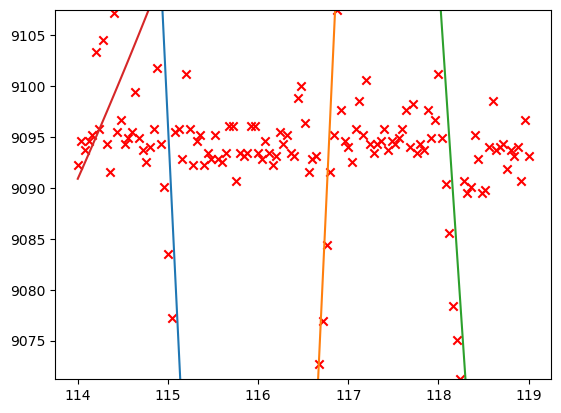

26 Roll = 0.28°


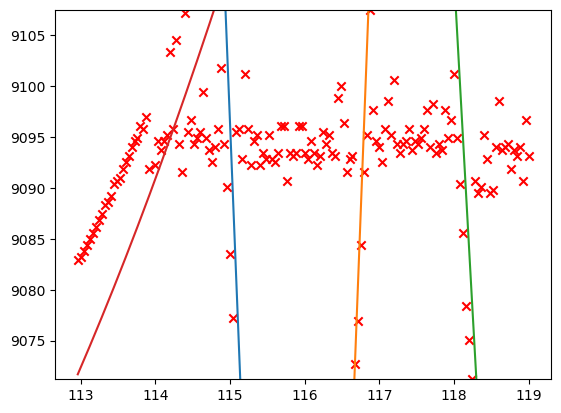

27 Roll = 0.00°


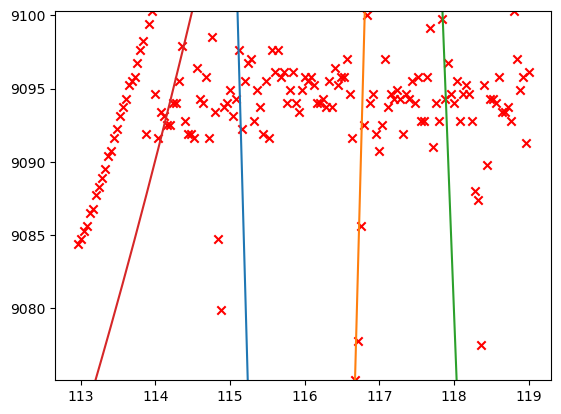

28 Roll = 1.28°


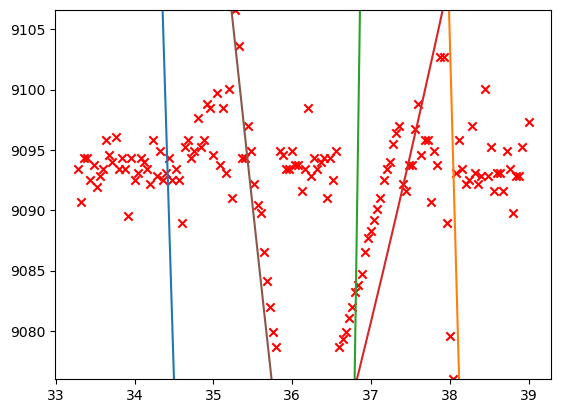

29 Roll = 1.28°


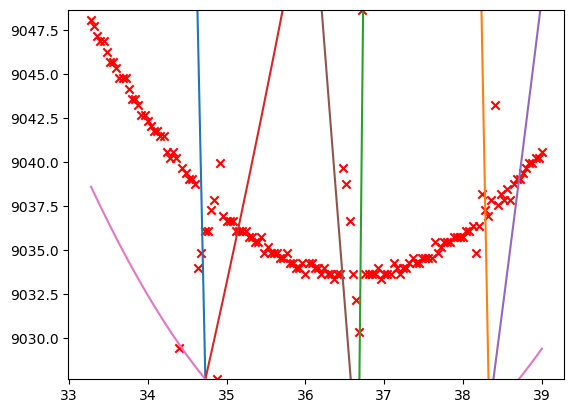

30 Roll = 0.28°


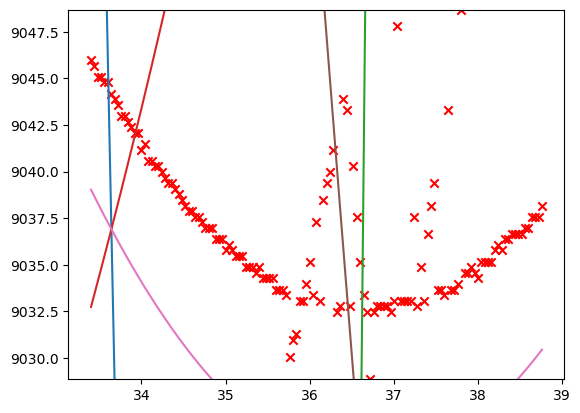

31 Roll = 1.28°


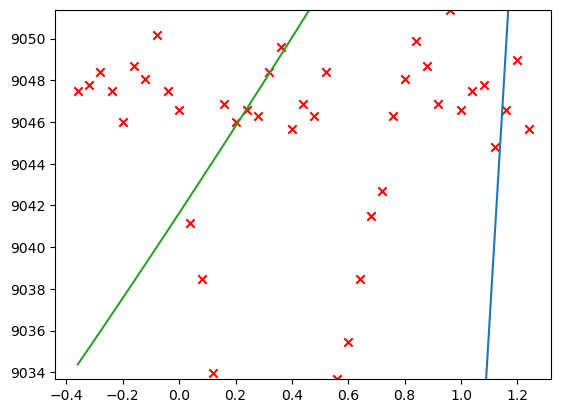

32 Roll = 0.66°


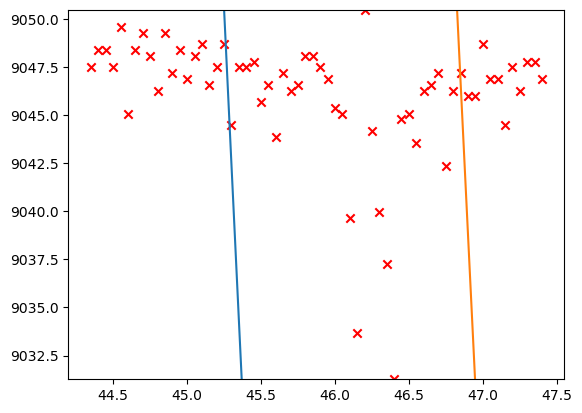

33 Roll = 0.40°


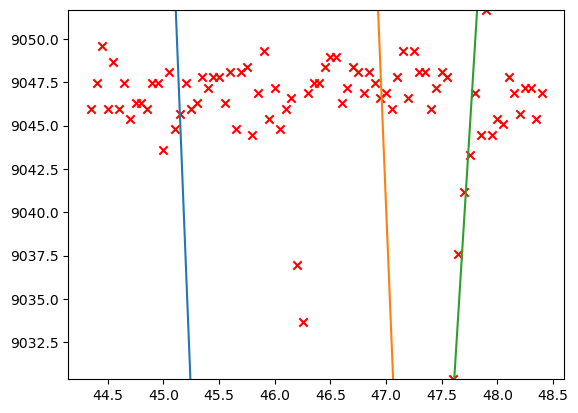

34 Roll = 1.40°


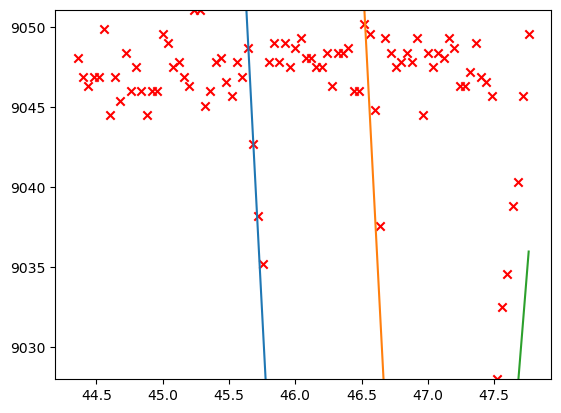

35 Roll = 1.20°


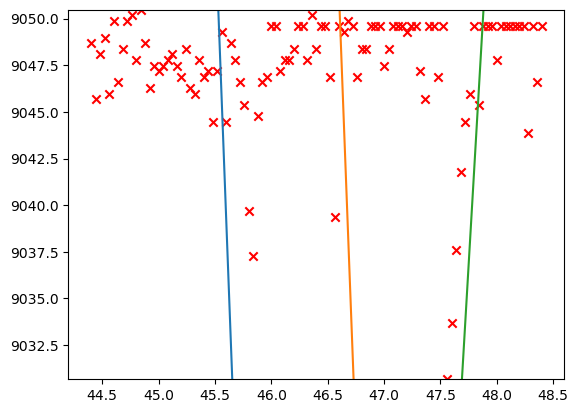

36 Roll = 0.00°


RuntimeError: Some Problems in the routine occured.
Switching back to original angles.

<Figure size 640x480 with 0 Axes>

In [130]:
for m in range(len(pitch_dict)):#1):#
    
    plt.figure()
    pitches = pitch_dict[str(m+1)]
    roll = roll_dict[str(m+1)]
    print(m,f"Roll = {roll:.2f}°")
    Eph_seed = np.array(seeding_energy_dict[str(m+1)])
    Pitch = np.deg2rad(pitches+dPconv)
    bmir.cryst.yaw = np.deg2rad(dYconv)
    if m != 0:
        PreSampling = bmir.BraggCurvesEvsAngles_inRange((Eph_seed.min()-30,Eph_seed.max()+30),PitchRange=[Pitch.min(),Pitch.max()],RollRange=np.deg2rad(roll+dRconv)+np.abs(np.pi/2-np.mean(Pitch))*dRPconv,numPreSampling=1000)
        Hquery_i = PreSampling[1]
    else:
        Hquery_i = [np.array([4,0,0])]
    plt.scatter(pitches,Eph_seed,marker='x',color='red')
    for Hidx, H in enumerate(Hquery_i):
        #print(lidx)
        #P0 = P0s[lidx]
        
        EBragg = getBragg_wPRcorr(Pitch,np.deg2rad(roll+dRconv),np.deg2rad(dYconv),dRPconv,H)+Ecorrconv

        #print(peval_sub.min(),peval_sub.max())
        plt.plot(pitches,EBragg)
        if m!=0:
            plt.ylim(Eph_seed.min(),Eph_seed.max())
    plt.show()

    

## Bayesian optimization of the roll, yaw and alpha parameters with respect to the extracted lines

In [ ]:

# Define the black box function to optimize.
def black_box_function(dthy, dthr, alpha):
    hmax = 8
    kmax = 8
    lmax = 8
    phen_list, p_angle_list, gid_list, linestyle_list, color_list = Bragg_plotter_limit(hmax, kmax, lmax, dthp, dthy, dthr, alpha, roll_angle, pitch)
    for phen, pangle, gid in zip(phen_list, p_angle_list, gid_list):
        ph_axis, pa_axis = [], []
        for ph_value, pa_value in zip(phen, pangle):
            # Only keep photon energies within a close range of the spectrometer image range
            if ph_value > np.min(seed_energy)-40 and ph_value < np.max(seed_energy)+40:
                global_ph.append(ph_value)
                global_pa.append(pa_value-dthp)
                global_gid.append(gid)
    dic = {'pitch_angle': global_pa, 'seed_energy_model': global_ph, 'gid': global_gid}
    df_model = pd.DataFrame(dic)
    df_model["pitch_angle"] = pd.to_numeric(df_model["pitch_angle"])
    # Create dataframe with the slope and intercept for each line found in this area
    res = df_model.groupby('gid').apply(lambda x: stats.linregress(x['pitch_angle'], x['seed_energy_model']))
    model_stats_df = pd.DataFrame(res.tolist(), index=res.index).reset_index().round(2)
    
    # Merge the measured and model data points
    df_meas = pd.merge(df, df_model, how="inner", on=["pitch_angle"])
    res = df_meas.groupby('gid').apply(lambda x: stats.linregress(x['pitch_angle'], x['seed_energy']))
    meas_stats_df = pd.DataFrame(res.tolist(), index=res.index).reset_index().round(2)
    meas_stats_df = meas_stats_df[meas_stats_df.pvalue < 0.5]

    # Merge the measured and model statistics dataframes
    df_merged = pd.merge(model_stats_df[['gid', 'slope', 'intercept']], meas_stats_df[['gid', 'slope', 'intercept']], how="inner", on=["gid"])
    df_merged['slope_delta'] = abs(df_merged['slope_x']-df_merged['slope_y'])
    df_merged['intercept_delta'] = abs(df_merged['intercept_x']-df_merged['intercept_y'])
    
    slope_cost=sum(df_merged['slope_delta'])**2
    intercept_cost=sum(df_merged['intercept_delta'])**2
    total_cost = 1/(slope_cost + (intercept_cost/10000))
    return total_cost


global_ph, global_pa, global_gid = [], [], []
seed_energy = np.array(seeding_energy)


# Measured data is fitted to lines
dic = {'pitch_angle': pitch, 'seed_energy': seed_energy}
df = pd.DataFrame(dic)
df["pitch_angle"] = pd.to_numeric(df["pitch_angle"])
df=df.drop_duplicates(['pitch_angle'])
    
# bayes_opt requires this to be a dictionary.
pbounds = {"dthy": [0.4, 0.45], "dthr": [0, 0.9], "alpha": [-0.005, 0]}# Create a BayesianOptimization optimizer,
# and optimize the given black_box_function.
optimizer = BayesianOptimization(f = black_box_function,
                                 pbounds = pbounds, verbose = 2,
                                 random_state = 4)
optimizer.maximize(init_points = 10, n_iter = 100)
print("Best result: {}; f(x) = {}.".format(optimizer.max["params"], optimizer.max["target"]))

|   iter    |  target   |   alpha   |   dthr    |   dthy    |
-------------------------------------------------------------
| 1         | 5.717e-07 | -0.000164 | 0.4925    | 0.4486    |
| 2         | 6.116e-07 | -0.001426 | 0.628     | 0.4108    |
| 3         | 6.446e-07 | -0.000118 | 0.005607  | 0.4126    |
| 4         | 6.491e-07 | -0.002826 | 0.7014    | 0.4099    |
| 5         | 6.68e-07  | -0.000685 | 0.8851    | 0.4082    |
| 6         | 7.147e-07 | -0.002013 | 0.008087  | 0.4193    |
| 7         | 7.267e-07 | -0.004779 | 0.861     | 0.4218    |
| 8         | 7.425e-07 | -0.000255 | 0.7077    | 0.4433    |
| 9         | 8.072e-07 | -0.004134 | 0.06745   | 0.43      |
| 10        | 7.992e-07 | -0.00416  | 0.66      | 0.4204    |
| 11        | 7.871e-07 | -0.001565 | 0.1325    | 0.427     |
| 12        | 7.748e-07 | -0.002921 | 0.876     | 0.4335    |
| 13        | 7.627e-07 | -0.002194 | 0.5785    | 0.441     |
| 14        | 7.529e-07 | -0.001912 | 0.3143    | 0.4373    |
| 15    

KeyboardInterrupt: 

## Plot the optimized model on top of the extracted measured lines

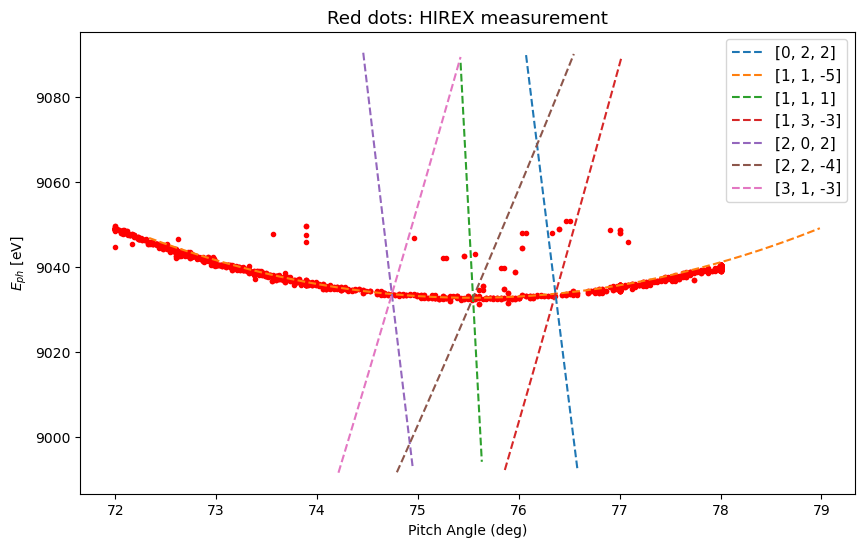

In [ ]:

dthy =optimizer.max["params"]['dthy']
dthr =optimizer.max["params"]['dthr']
alpha = optimizer.max["params"]['alpha']
dthp = 1.335


global_ph, global_pa, global_gid = [], [], []
seed_energy = np.array(seeding_energy)
pitch_list = np.linspace(min(pitch)-1,max(pitch),400) 
phen_list, p_angle_list, gid_list, linestyle_list, color_list = Bragg_plotter_limit(5, 5, 5, dthp, dthy, dthr, alpha, roll_angle, pitch_list)
fig, ax = plt.subplots(figsize=(10,6))
plt.plot(pitch, seed_energy, 'r.')

for phen, pangle, gid in zip(phen_list, p_angle_list, gid_list):
        ph_axis, pa_axis = [], []
        for ph_value, pa_value in zip(phen, pangle):
            # Only keep photon energies within a close range of the spectrometer image range
            if ph_value > np.min(seed_energy)-40 and ph_value < np.max(seed_energy)+40 and pa_value >= min(pitch_list)-1 and pa_value <= max(pitch_list)+1:
                ph_axis.append(ph_value)
                pa_axis.append(pa_value)
                
        if ph_axis == []:
            pass
        else:
            plt.plot(pa_axis, ph_axis, '--', label=gid)
ax.set_xlabel('Pitch Angle (deg)')
ax.set_ylabel(r'$E_{ph}$ [eV]')
plt.rcParams.update({'font.size': 11})
#ax.set_ylim(np_phen[0], np_phen[-1])
#ax.set_xlim(doocs_scale[0], doocs_scale[-1])
ax.legend(loc='best')
plt.title('Red dots: HIREX measurement')
plt.show()
